# Remote Sensing of Snow and Ice with BioSNICAR
## From Satellite Pixels to Physical Properties

This notebook takes you from **"what is remote sensing?"** to running a
complete multi-parameter satellite retrieval pipeline.  No prior knowledge
of radiative transfer or remote sensing is assumed — every concept is built
from first principles using lightweight toy models before connecting to
the real BioSNICAR codebase.

| Act | Sections | Topic |
|-----|----------|-------|
| **I** | 1–5 | What Satellites See — spectra, bands, SRFs, platforms, indices |
| **II** | 6–9 | Bridging Spectra and Bands — forward problem, information content, multi-platform |
| **III** | 10–14 | The Inverse Problem in Practice — degeneracy, log-space, uncertainty, masking |
| **IV** | 15–18 | Building and Using the Emulator — speed, default emulator, custom builds, retrieval API |
| **V** | 19–23 | Real-World Retrieval Scenarios — SSA, Sentinel-2, MCMC, multi-param, time-series |
| **VI** | 24–25 | Putting It All Together — capstone pipeline (optional) and decision guide |

All sections except the optional capstone (Section 24) run on standard
scientific Python.  BioSNICAR is only required for Section 24 and is
detected automatically.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize, stats
from pathlib import Path
import warnings, time

warnings.filterwarnings("ignore", category=FutureWarning)
np.random.seed(42)

# --- Plotting defaults ---
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "font.size": 9,
    "legend.fontsize": 8,
    "figure.figsize": (8, 4),
    "axes.grid": True,
    "grid.alpha": 0.3,
})

# --- Shared wavelength grid (matches BioSNICAR's 480 bands) ---
WVL = np.arange(0.205, 4.999, 0.01)  # shape (480,), µm
N_WVL = len(WVL)

# --- Load real ice imaginary refractive index ---
# This is the same data BioSNICAR uses internally (Warren & Brandt 2008 /
# Picard et al. 2016).  Loading it directly ensures our toy spectra have
# the correct spectral features.
_k_ice_path = Path(__file__).resolve().parent.parent / "data" / "OP_data" / "k_ice_480.csv" \
    if "__file__" in dir() else Path("../data/OP_data/k_ice_480.csv")
if not _k_ice_path.exists():
    _k_ice_path = Path("data/OP_data/k_ice_480.csv")  # fallback: run from repo root

if _k_ice_path.exists():
    _k_raw = np.loadtxt(_k_ice_path)
    _wvl_raw = np.linspace(0.205, 4.995, len(_k_raw))
    K_ICE = np.interp(WVL, _wvl_raw, _k_raw)
    print(f"Loaded real ice absorption data from {_k_ice_path.name} ({len(_k_raw)} → {N_WVL} bands)")
else:
    # Fallback: minimal parametric approximation (less accurate)
    K_ICE = 2e-9 * np.ones(N_WVL)
    K_ICE += 1e-8 * (WVL / 0.7)**6
    K_ICE += 2.5e-6 * np.exp(-((WVL - 1.03) / 0.03)**2)
    K_ICE += 1.5e-5 * np.exp(-((WVL - 1.25) / 0.05)**2)
    K_ICE += 6e-4 * np.exp(-((WVL - 1.50) / 0.07)**2)
    K_ICE += 1.8e-3 * np.exp(-((WVL - 2.00) / 0.09)**2)
    K_ICE += 0.5 * np.exp(-((WVL - 3.10) / 0.25)**2)
    print("Warning: k_ice_480.csv not found — using parametric fallback.")

# --- Optional BioSNICAR import ---
try:
    import biosnicar
    BIOSNICAR_AVAILABLE = True
except ImportError:
    BIOSNICAR_AVAILABLE = False
    print("biosnicar not installed — Section 24 (capstone) will be skipped.")

print(f"Wavelength grid: {N_WVL} bands, {WVL[0]:.3f}–{WVL[-1]:.3f} µm")
print("Setup complete.")

Loaded real ice absorption data from k_ice_480.csv (4800 → 480 bands)
Wavelength grid: 480 bands, 0.205–4.995 µm
Setup complete.


## Shared Toy Model

Before we begin, we define a **parametric snow/ice spectrum** that serves as
our toy forward model throughout the notebook.  It maps physical parameters
to a 480-band spectral albedo — the same output shape as BioSNICAR's real
forward model.

The primary surface parameter is the **specific surface area (SSA)**,
which combines grain size and density into a single variable that controls
scattering:

$$\text{SSA} = \frac{3}{r_{\text{eff}} \cdot \rho_{\text{ice}}}$$

where $r_{\text{eff}}$ is effective grain radius (m) and $\rho_{\text{ice}}$ = 917 kg m⁻³.

The spectral albedo uses the **Kokhanovsky (2004) approximation** for a
semi-infinite snowpack:

$$\alpha(\lambda) \approx \exp\!\left(-\alpha_0\,\sqrt{\gamma(\lambda)\,r_{\text{eff}}}\right)$$

where $\gamma(\lambda) = 4\pi\kappa(\lambda)/\lambda$ is the bulk ice
absorption coefficient computed from the **imaginary refractive index
of ice** ($\kappa$, loaded from `data/OP_data/k_ice_480.csv`).  Because we
use the same $\kappa(\lambda)$ data as BioSNICAR, our toy spectra have
the correct absorption band structure — the characteristic features at
1.03, 1.25, 1.5, and 2.0 µm appear in the right places with the right
relative depths.

A small **Fresnel floor** (~2% reflectance) prevents the albedo from
reaching exactly zero at strongly absorbing wavelengths, matching the
physical minimum set by surface reflection off ice grain facets.

In [2]:
# --- Toy forward model ---
# Mirrors the BioSNICAR pipeline: params → spectral albedo (480 bands).
# Uses real ice absorption data (K_ICE) loaded in the setup cell.

def toy_solar_flux(wvl):
    """Approximate top-of-atmosphere solar flux (W m⁻² µm⁻¹)."""
    T = 5778.0
    c1 = 3.742e8   # 2πhc² in W µm⁴ m⁻²
    c2 = 1.439e4   # hc/k in µm K
    B = c1 / (wvl**5 * (np.exp(c2 / (wvl * T)) - 1))
    return B / B.max()

def toy_impurity_mac(wvl, impurity_type="black_carbon"):
    """Toy mass absorption cross-section (m² kg⁻¹).

    Absorption band widths approximate the broad spectral envelopes
    of real pigments (carotenoids, chlorophyll-a) and minerals.
    """
    if impurity_type == "black_carbon":
        # Smooth power law — absorbs across the full VIS
        return 7.5 * (0.55 / wvl)**1.1
    elif impurity_type == "snow_algae":
        # Astaxanthin (broad carotenoid ~480 nm) + Chl-a (~680 nm)
        mac = 0.4 * np.exp(-((wvl - 0.48) / 0.07)**2)
        mac += 0.3 * np.exp(-((wvl - 0.68) / 0.05)**2)
        return mac
    elif impurity_type == "glacier_algae":
        # Broad VIS absorption: carotenoid + Soret (~470 nm),
        # Chl-a Q-band (~670 nm), weak green bridge (~550 nm)
        mac = 0.8 * np.exp(-((wvl - 0.47) / 0.06)**2)
        mac += 0.6 * np.exp(-((wvl - 0.67) / 0.05)**2)
        mac += 0.2 * np.exp(-((wvl - 0.55) / 0.08)**2)
        return mac
    elif impurity_type == "dust":
        return 0.3 * (0.55 / wvl)**2.5
    return np.zeros_like(wvl)

RHO_ICE = 917.0  # density of solid ice (kg m⁻³)
R_FRESNEL = 0.02  # Fresnel reflectance at air-ice interface (~2%)

def ssa_to_rds(ssa):
    """Convert SSA (m² kg⁻¹) to effective grain radius (µm)."""
    return 3.0 / (ssa * RHO_ICE) * 1e6

def rds_to_ssa(rds_um):
    """Convert effective grain radius (µm) to SSA (m² kg⁻¹)."""
    return 3.0 / (rds_um * 1e-6 * RHO_ICE)

# Cache solar flux
_FLX_SOLAR = toy_solar_flux(WVL)

def toy_spectrum(ssa=None, rds=None, black_carbon=0, snow_algae=0,
                 glacier_algae=0, dust=0, solzen=50, dz=1.0,
                 direct=1, wvl=None):
    """Parametric snow/ice forward model → 480-band spectral albedo.

    Uses the Kokhanovsky (2004) approximation with real ice absorption
    data and a Fresnel reflectance floor.

    Parameters
    ----------
    ssa : float or None
        Specific surface area (m² kg⁻¹), 0.5–65.  Primary parameter.
        If None, computed from rds.
    rds : float or None
        Effective grain radius (µm), 50–5000.  Alternative to ssa.
    black_carbon, snow_algae, glacier_algae, dust : float
        Impurity concentrations (ppb or cells/mL).
    solzen : float
        Solar zenith angle (degrees), 0–89.
    dz : float
        Ice thickness (m), 0.01–10.
    direct : int
        1 = direct beam, 0 = diffuse.

    Returns
    -------
    albedo : ndarray (480,)
        Spectral albedo (0–1).
    """
    # Resolve SSA
    if ssa is None and rds is None:
        ssa = 20.0
    elif ssa is None:
        ssa = rds_to_ssa(rds)

    if wvl is None:
        wvl_use = WVL
        k_ice = K_ICE
    else:
        # Resample k_ice to custom grid
        k_ice = np.interp(wvl, WVL, K_ICE)
        wvl_use = wvl

    # Effective grain radius (m)
    r_eff = 3.0 / (ssa * RHO_ICE)

    # Bulk absorption coefficient (m⁻¹)
    gamma = 4.0 * np.pi * k_ice / (wvl_use * 1e-6)

    # Kokhanovsky approximation: α ≈ exp(-α₀ √(γ·r_eff))
    # α₀ ≈ 4.0 (tuned to match BioSNICAR adding-doubling output)
    alpha_0 = 4.0
    vol_scatter = np.exp(-alpha_0 * np.sqrt(np.maximum(gamma * r_eff, 0)))

    # Fresnel floor: surface reflection prevents albedo reaching zero
    fresnel = R_FRESNEL * np.exp(-0.1 * gamma * r_eff)
    grain_albedo = vol_scatter * (1 - R_FRESNEL) + fresnel

    # Impurity absorption (additive in optical depth)
    imp_abs = np.zeros_like(wvl_use)
    if black_carbon > 0:
        imp_abs += (black_carbon / 1000) * toy_impurity_mac(wvl_use, "black_carbon")
    if snow_algae > 0:
        imp_abs += (snow_algae / 10000) * toy_impurity_mac(wvl_use, "snow_algae")
    if glacier_algae > 0:
        imp_abs += (glacier_algae / 10000) * toy_impurity_mac(wvl_use, "glacier_algae")
    if dust > 0:
        imp_abs += (dust / 5000) * toy_impurity_mac(wvl_use, "dust")
    imp_factor = np.exp(-imp_abs)

    # Solar zenith: higher angles → longer path → lower albedo
    mu0 = np.cos(np.radians(solzen))
    zen_factor = (0.85 + 0.15 * mu0) if direct else 0.90

    # Thickness: thin layers transmit more
    thick_factor = 1.0 - np.exp(-dz * 5.0)

    albedo = grain_albedo * imp_factor * zen_factor * thick_factor
    return np.clip(albedo, 0, 1)

def compute_ssa(rds_um, rho=RHO_ICE):
    """SSA in m² kg⁻¹ (matches inverse/result.py:16)."""
    return 3.0 / (rds_um * 1e-6 * rho)

# Quick test — the features at 1.03, 1.25, 1.5, 2.0 µm come from real ice data
a_fresh = toy_spectrum(ssa=50)  # fresh snow (r≈65 µm)
a_aged = toy_spectrum(ssa=10)   # aged snow (r≈327 µm)
a_dirty = toy_spectrum(ssa=3, black_carbon=100)  # dirty glacier ice

print(f"Fresh snow  (SSA=50): VIS={np.mean(a_fresh[(WVL>0.4)&(WVL<0.7)]):.3f}  "
      f"1.0µm={a_fresh[np.argmin(np.abs(WVL-1.0))]:.3f}  "
      f"1.5µm={a_fresh[np.argmin(np.abs(WVL-1.5))]:.3f}")
print(f"Aged snow   (SSA=10): VIS={np.mean(a_aged[(WVL>0.4)&(WVL<0.7)]):.3f}  "
      f"1.0µm={a_aged[np.argmin(np.abs(WVL-1.0))]:.3f}  "
      f"1.5µm={a_aged[np.argmin(np.abs(WVL-1.5))]:.3f}")
print(f"Dirty ice   (SSA=3):  VIS={np.mean(a_dirty[(WVL>0.4)&(WVL<0.7)]):.3f}  "
      f"1.0µm={a_dirty[np.argmin(np.abs(WVL-1.0))]:.3f}  "
      f"1.5µm={a_dirty[np.argmin(np.abs(WVL-1.5))]:.3f}")

Fresh snow  (SSA=50): VIS=0.932  1.0µm=0.824  1.5µm=0.122
Aged snow   (SSA=10): VIS=0.923  1.0µm=0.701  1.5µm=0.023
Dirty ice   (SSA=3):  VIS=0.422  1.0µm=0.373  1.5µm=0.009


---

# Act I — What Satellites See

Act I introduces the fundamentals of satellite remote sensing: what
electromagnetic radiation reaches the sensor, why satellites divide
the spectrum into discrete bands, and how spectral indices compress
band data into diagnostic numbers.

## Section 1: What Is Remote Sensing?

**Remote sensing** is the measurement of electromagnetic radiation reflected
or emitted by the Earth's surface, collected by a sensor that is not in
direct contact with the surface.  For snow and ice, we focus on the
**solar window** (0.3–2.5 µm) where sunlight illuminates the surface and
the reflected fraction — the **albedo** — encodes information about
the surface's physical properties.

The basic geometry is:

1. **Sun** emits broadband radiation (peak ~0.5 µm).
2. **Surface** absorbs and scatters photons depending on its structure
   (grain size, density, impurities, wetness).
3. **Sensor** (on a satellite, drone, or tripod) records the reflected
   radiation in discrete wavelength intervals called **bands**.

**Albedo** ($\alpha$) is the fraction of incident radiation reflected:

$$\alpha(\lambda) = \frac{F^{\uparrow}(\lambda)}{F^{\downarrow}(\lambda)}$$

A perfectly white surface has $\alpha = 1$; a perfectly absorbing surface
has $\alpha = 0$.  Fresh snow can exceed $\alpha = 0.95$ in the visible
but drops below 0.1 in the thermal infrared — this strong wavelength
dependence is what makes spectral remote sensing powerful.

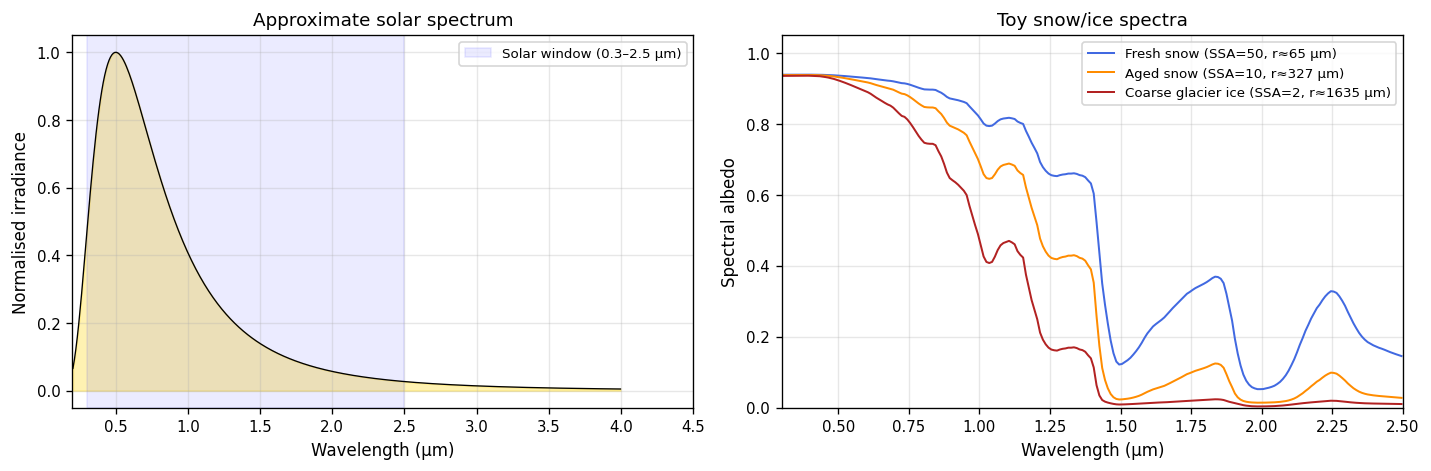

In [3]:
# --- Section 1: Solar spectrum and toy snow spectra ---

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Left: Solar spectrum
flx = toy_solar_flux(WVL)
ax1.fill_between(WVL[WVL < 4], flx[WVL < 4], alpha=0.3, color="gold")
ax1.plot(WVL[WVL < 4], flx[WVL < 4], "k-", lw=0.8)
ax1.axvspan(0.3, 2.5, alpha=0.08, color="blue", label="Solar window (0.3–2.5 µm)")
ax1.set(xlabel="Wavelength (µm)", ylabel="Normalised irradiance",
        title="Approximate solar spectrum", xlim=(0.2, 4.5))
ax1.legend()

# Right: Three toy snow/ice spectra — note realistic absorption bands
vis_nir = WVL < 2.5
for ssa_val, label, color in [
    (50, "Fresh snow (SSA=50, r≈65 µm)", "royalblue"),
    (10, "Aged snow (SSA=10, r≈327 µm)", "darkorange"),
    (2,  "Coarse glacier ice (SSA=2, r≈1635 µm)", "firebrick"),
]:
    ax2.plot(WVL[vis_nir], toy_spectrum(ssa=ssa_val)[vis_nir],
             color=color, label=label, lw=1.2)
ax2.set(xlabel="Wavelength (µm)", ylabel="Spectral albedo",
        title="Toy snow/ice spectra", xlim=(0.3, 2.5), ylim=(0, 1.05))
ax2.legend(fontsize=8)

fig.tight_layout()
plt.show()

**Figure 1.** *(Left)* Normalised top-of-atmosphere solar irradiance as a
function of wavelength, approximated by a 5778 K black body.  The shaded
region marks the 0.3–2.5 µm solar window where reflected-light remote
sensing operates.  *(Right)* Spectral albedo for three clean snow/ice
surfaces spanning SSA = 50 (fresh snow, r ≈ 65 µm) to SSA = 2 (coarse
glacier ice, r ≈ 1635 µm).  All three share high visible albedo
(> 0.9) but diverge sharply in the near-infrared, where ice absorption
bands at 1.03, 1.25, 1.5, and 2.0 µm deepen with decreasing SSA.

### Key observations

1. **Visible (0.3–0.7 µm):** Snow is very bright and relatively insensitive
   to grain size / SSA — all three curves nearly overlap.
2. **Near-infrared (0.7–2.5 µm):** Albedo drops at specific wavelengths
   (1.03, 1.25, 1.5, 2.0 µm) corresponding to **ice absorption bands**.
   The depth of these features is strongly SSA-dependent — lower SSA
   (bigger grains) means deeper absorption.
3. **Between absorption bands** (e.g., 1.1 and 1.7 µm), albedo partially
   recovers.  This characteristic "bumpy" structure is the spectral
   fingerprint of ice.
4. **Solar flux weighting:** Most solar energy arrives in the visible, so the
   broadband albedo is dominated by visible wavelengths even though NIR
   bands carry more diagnostic information about ice structure.

> **BioSNICAR connection** — The real forward model in
> `biosnicar/drivers/run_model.py` produces the same output: a 480-band
> spectral albedo on the grid defined by `biosnicar/bands/_core.py:14`
> (`WVL = np.arange(0.205, 4.999, 0.01)`).  Our toy function mimics
> this interface so that everything we build in this notebook transfers
> directly to the real model.

## Section 2: From Continuous Spectra to Discrete Bands

A spectrometer records albedo at hundreds of wavelengths, but satellite
sensors typically measure in only 5–20 **spectral bands**.  Why?

1. **Signal-to-noise ratio (SNR):** Collecting photons over a wider
   wavelength range increases the signal.  Narrow bands are noisy.
2. **Data volume:** 480 bands per pixel × millions of pixels × daily
   revisit = enormous data.  A handful of well-chosen bands captures
   most information.
3. **Engineering:** Detector technology limits how many bands can be
   measured simultaneously.

A **band** integrates the continuous spectrum over a wavelength interval.
The simplest model is a **rectangular (tophat) filter**:

$$\alpha_{\text{band}} = \frac{\int_{\lambda_1}^{\lambda_2} \alpha(\lambda)\, F(\lambda)\, d\lambda}{\int_{\lambda_1}^{\lambda_2} F(\lambda)\, d\lambda}$$

where $F(\lambda)$ is the solar flux.  This **flux-weighted** average
ensures that wavelengths contributing more energy count more.

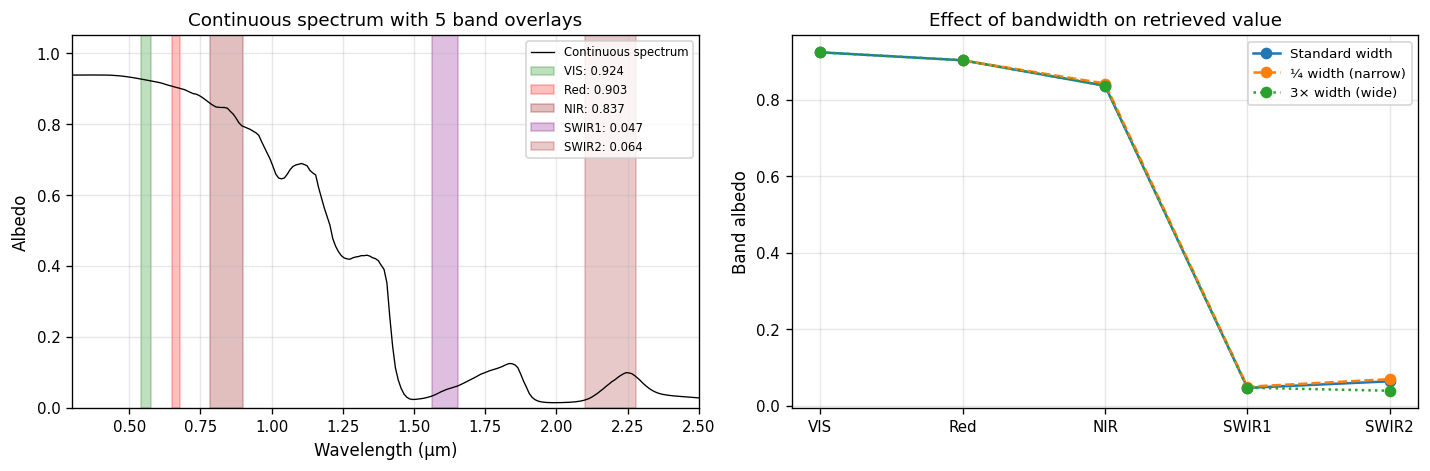

In [4]:
# --- Section 2: Band convolution demonstration ---

def tophat_srf(wvl, centre, half_width):
    """Create a rectangular (tophat) spectral response function."""
    return ((wvl >= centre - half_width) & (wvl < centre + half_width)).astype(float)

def flux_weighted_band(albedo, flx, srf):
    """Flux-weighted SRF convolution — matches biosnicar/bands/_core.py:56."""
    weight = srf * flx
    denom = np.sum(weight)
    if denom == 0:
        return np.nan
    return float(np.sum(albedo * weight) / denom)

# Define toy bands (similar to Sentinel-2)
TOY_BANDS = {
    "VIS":  (0.560, 0.0175),  # Green
    "Red":  (0.665, 0.015),   # Red
    "NIR":  (0.842, 0.0575),  # Broad NIR
    "SWIR1": (1.610, 0.045),  # Shortwave IR 1
    "SWIR2": (2.190, 0.090),  # Shortwave IR 2
}

spectrum = toy_spectrum(ssa=10)  # aged snow

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Left: spectrum with band overlays
ax1.plot(WVL, spectrum, "k-", lw=0.8, label="Continuous spectrum")
colors = ["green", "red", "darkred", "purple", "brown"]
band_vals = {}
for (name, (cen, hw)), color in zip(TOY_BANDS.items(), colors):
    srf = tophat_srf(WVL, cen, hw)
    val = flux_weighted_band(spectrum, _FLX_SOLAR, srf)
    band_vals[name] = val
    ax1.axvspan(cen - hw, cen + hw, alpha=0.25, color=color, label=f"{name}: {val:.3f}")
ax1.set(xlabel="Wavelength (µm)", ylabel="Albedo", xlim=(0.3, 2.5), ylim=(0, 1.05),
        title="Continuous spectrum with 5 band overlays")
ax1.legend(fontsize=7)

# Right: narrow vs wide band comparison
for hw_mult, ls, label in [(1, "-", "Standard width"), (0.25, "--", "¼ width (narrow)"),
                             (3, ":", "3× width (wide)")]:
    vals = []
    for name, (cen, hw) in TOY_BANDS.items():
        srf = tophat_srf(WVL, cen, hw * hw_mult)
        vals.append(flux_weighted_band(spectrum, _FLX_SOLAR, srf))
    ax2.plot(list(TOY_BANDS.keys()), vals, ls + "o", label=label)
ax2.set(ylabel="Band albedo", title="Effect of bandwidth on retrieved value")
ax2.legend()

fig.tight_layout()
plt.show()

**Figure 2.** *(Left)* A 480-band albedo spectrum (aged snow, SSA = 10)
overlaid with five tophat spectral response functions (VIS, Red, NIR,
SWIR1, SWIR2).  Each coloured bar spans the band's wavelength range;
the label gives the flux-weighted band-average albedo.  *(Right)* The
effect of bandwidth on the retrieved band value: narrow bands (¼ width)
sample a smaller spectral region and can differ from the standard-width
result, while wide bands (3× width) smooth out spectral features.  The
differences are largest for SWIR bands where the spectrum changes
rapidly.

### Key observations

1. **Each band is a single number** — a weighted average of all albedo
   values within the band's spectral range.  Going from 480 bands to 5
   loses information, but the 5 values still capture the overall spectral
   shape.
2. **Bandwidth matters:** Very narrow bands give noisy, unstable values;
   very wide bands smear out spectral features.  The standard widths are
   an engineering compromise.
3. **Flux weighting matters:** Because solar flux peaks in the visible and
   drops in the SWIR, a simple arithmetic average would over-weight
   low-flux wavelengths.  Flux weighting gives a physically meaningful
   result.

## Section 3: Spectral Response Functions

Real satellite bands aren't perfect rectangles.  Each detector has a
**spectral response function (SRF)** that describes its sensitivity as a
function of wavelength.  The SRF might look roughly Gaussian, or have
side lobes, or be deliberately shaped by optical filters.

The convolution formula generalises to:

$$\alpha_{\text{band}} = \frac{\sum_i \alpha(\lambda_i)\, \text{SRF}(\lambda_i)\, F(\lambda_i)}{\sum_i \text{SRF}(\lambda_i)\, F(\lambda_i)}$$

This is exactly the formula implemented in `biosnicar/bands/_core.py:56`
(`srf_convolve()`).  The key point: **the SRF and solar flux together
determine the weighting** — wavelengths where both the SRF and the flux
are large dominate the average.

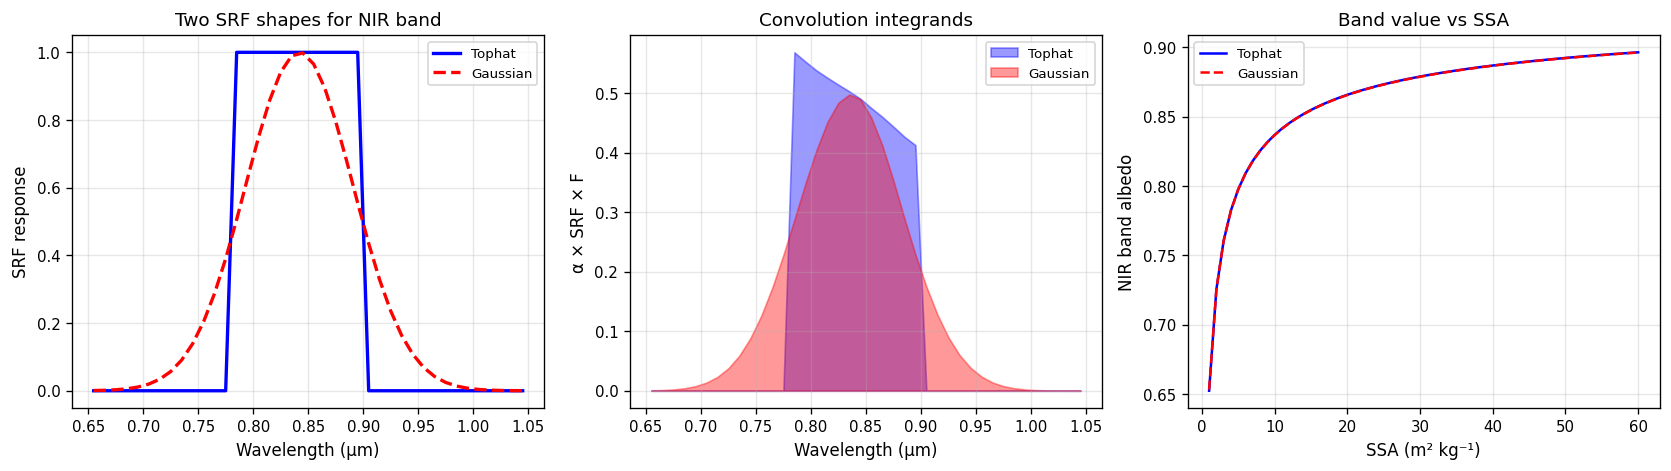

Tophat NIR albedo (SSA=10):  0.8367
Gaussian NIR albedo (SSA=10): 0.8366
Difference: 0.0001


In [5]:
# --- Section 3: SRF shape comparison ---

def gaussian_srf(wvl, centre, fwhm):
    """Gaussian SRF with given FWHM."""
    sigma = fwhm / (2 * np.sqrt(2 * np.log(2)))
    return np.exp(-0.5 * ((wvl - centre) / sigma)**2)

centre, hw = 0.842, 0.0575  # NIR band

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Panel 1: SRF shapes
th = tophat_srf(WVL, centre, hw)
gs = gaussian_srf(WVL, centre, hw * 2)  # FWHM ~ full width
mask = (WVL > 0.65) & (WVL < 1.05)
axes[0].plot(WVL[mask], th[mask], "b-", lw=2, label="Tophat")
axes[0].plot(WVL[mask], gs[mask], "r--", lw=2, label="Gaussian")
axes[0].set(xlabel="Wavelength (µm)", ylabel="SRF response",
            title="Two SRF shapes for NIR band")
axes[0].legend()

# Panel 2: Convolution integrand (albedo × SRF × flux)
spectrum = toy_spectrum(ssa=10)
integrand_th = spectrum * th * _FLX_SOLAR
integrand_gs = spectrum * gs * _FLX_SOLAR
axes[1].fill_between(WVL[mask], integrand_th[mask], alpha=0.4, color="blue", label="Tophat")
axes[1].fill_between(WVL[mask], integrand_gs[mask], alpha=0.4, color="red", label="Gaussian")
axes[1].set(xlabel="Wavelength (µm)", ylabel="α × SRF × F",
            title="Convolution integrands")
axes[1].legend()

# Panel 3: Resulting band values across SSA values
ssa_range = np.linspace(1, 60, 60)
vals_th, vals_gs = [], []
for s in ssa_range:
    spec = toy_spectrum(ssa=s)
    vals_th.append(flux_weighted_band(spec, _FLX_SOLAR, th))
    vals_gs.append(flux_weighted_band(spec, _FLX_SOLAR, gs))
axes[2].plot(ssa_range, vals_th, "b-", label="Tophat")
axes[2].plot(ssa_range, vals_gs, "r--", label="Gaussian")
axes[2].set(xlabel="SSA (m² kg⁻¹)", ylabel="NIR band albedo",
            title="Band value vs SSA")
axes[2].legend()

fig.tight_layout()
plt.show()

print(f"Tophat NIR albedo (SSA=10):  {vals_th[9]:.4f}")
print(f"Gaussian NIR albedo (SSA=10): {vals_gs[9]:.4f}")
print(f"Difference: {abs(vals_th[9] - vals_gs[9]):.4f}")

**Figure 3.** *(Left)* Two spectral response function shapes — a tophat
and a Gaussian of equal FWHM — for the NIR band centred at 0.842 µm.
*(Centre)* The convolution integrand (albedo × SRF × solar flux) for
each shape, showing the quantity that is integrated to produce the band
value.  The Gaussian extends beyond the tophat edges, including
slightly different spectral regions.  *(Right)* Band-averaged NIR
albedo as a function of SSA for both SRF shapes, demonstrating that
the tophat approximation introduces negligible error for this
broad band.

### Key observations

1. **SRF shape matters less than you'd think** for broadish bands.  The
   tophat and Gaussian give similar band values because the underlying
   spectrum changes slowly across the band.
2. **It matters more for narrow features** — if the albedo has a sharp
   absorption line within the band, the SRF tails can include or exclude
   it, changing the result.
3. **BioSNICAR uses tophat approximations** (from published band centres
   and widths) stored as CSV files in `data/band_srfs/`.  These can be
   replaced with manufacturer-measured SRFs when available.

> **BioSNICAR connection** — `biosnicar/bands/_core.py:21` (`load_srf()`)
> reads SRF CSVs and caches them.  `srf_convolve()` (line 56) implements
> the flux-weighted convolution.  The tophat CSVs live in
> `data/band_srfs/sentinel2_msi.csv`, etc.

## Section 4: Meet the Platforms

BioSNICAR supports **8 satellite/model platforms**, each with a different
number of bands and spectral coverage:

| Platform | Bands | Range (µm) | Method | Type |
|----------|-------|-----------|--------|------|
| Sentinel-2 MSI | 13 | 0.44–2.19 | SRF convolution | Satellite |
| Sentinel-3 OLCI | 21 | 0.40–1.02 | SRF convolution | Satellite |
| Landsat 8 OLI | 7 | 0.44–2.20 | SRF convolution | Satellite |
| MODIS | 7 (+3 broadband) | 0.47–2.13 | SRF convolution | Satellite |
| CESM2 (2-band) | 2 | 0.2–5.0 | Interval average | Climate model |
| CESM RRTMG | 14 | 0.2–12.2 | Interval average | Climate model |
| MAR | 4 | 0.25–4.0 | Interval average | Climate model |
| HadCM3 | 6 | 0.2–5.0 | Interval average | Climate model |

**SRF convolution** uses the platform's spectral response functions.
**Interval averaging** computes flux-weighted means over fixed wavelength
ranges — appropriate for climate models whose radiation schemes work in
broad intervals.

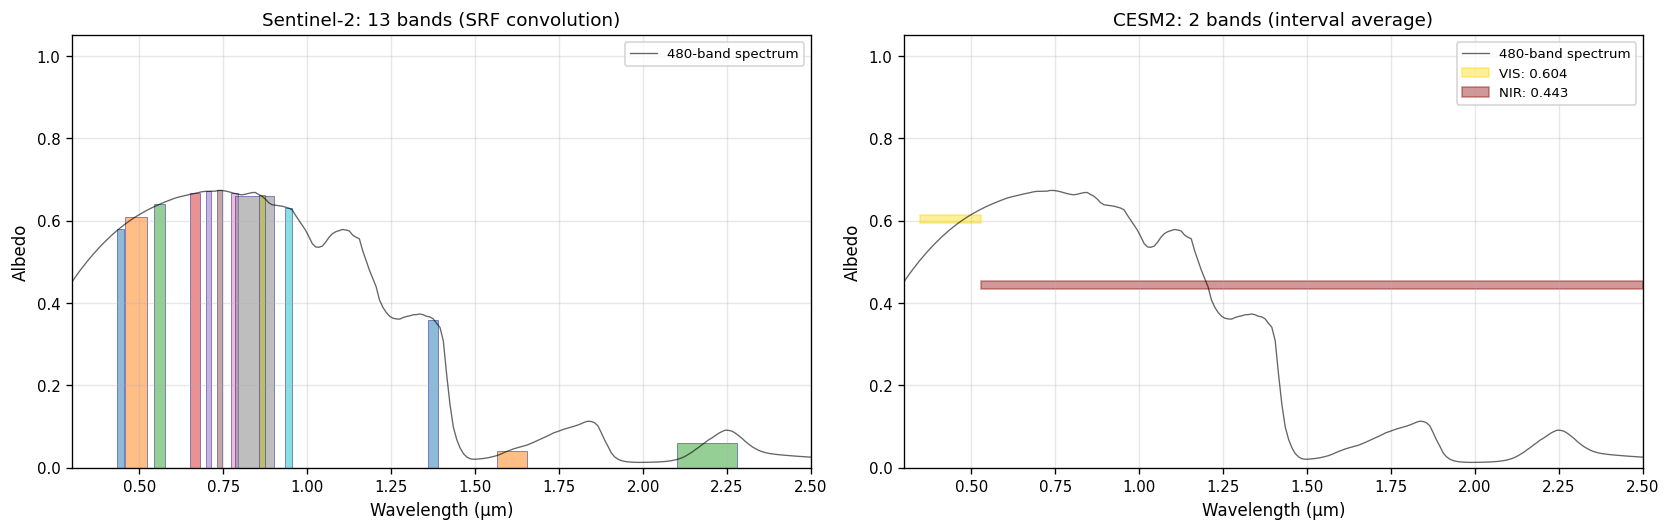


Sentinel-2 carries 13 bands of information.
CESM2 carries 2 bands — massive information loss.


In [6]:
# --- Section 4: Platform comparison ---

# Sentinel-2 band definitions (from biosnicar/bands/platforms/sentinel2.py)
S2_BANDS = {
    "B1":  (0.443, 0.010), "B2":  (0.490, 0.0325), "B3":  (0.560, 0.0175),
    "B4":  (0.665, 0.015), "B5":  (0.705, 0.0075), "B6":  (0.740, 0.0075),
    "B7":  (0.783, 0.010), "B8":  (0.842, 0.0575), "B8A": (0.865, 0.010),
    "B9":  (0.945, 0.010), "B10": (1.375, 0.015),  "B11": (1.610, 0.045),
    "B12": (2.190, 0.090),
}

# CESM 2-band intervals
CESM2_BANDS = {"VIS": (0.3, 0.7), "NIR": (0.7, 5.0)}

def interval_average(albedo, flx, lo, hi):
    """Flux-weighted mean over [lo, hi) — matches _core.py:80."""
    mask = (WVL >= lo) & (WVL < hi)
    w = flx[mask]
    return float(np.sum(albedo[mask] * w) / np.sum(w)) if np.sum(w) > 0 else np.nan

spectrum = toy_spectrum(ssa=10, black_carbon=50)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

# Left: S2 13-band overlay
ax1.plot(WVL, spectrum, "k-", lw=0.8, alpha=0.6, label="480-band spectrum")
s2_names, s2_vals = [], []
for name, (cen, hw) in S2_BANDS.items():
    srf = tophat_srf(WVL, cen, hw)
    val = flux_weighted_band(spectrum, _FLX_SOLAR, srf)
    s2_names.append(name)
    s2_vals.append(val)
    ax1.bar(cen, val, width=hw * 2, alpha=0.5, edgecolor="navy", linewidth=0.5)
ax1.set(xlabel="Wavelength (µm)", ylabel="Albedo", xlim=(0.3, 2.5), ylim=(0, 1.05),
        title="Sentinel-2: 13 bands (SRF convolution)")
ax1.legend()

# Right: CESM 2-band overlay
ax2.plot(WVL, spectrum, "k-", lw=0.8, alpha=0.6, label="480-band spectrum")
cesm_colors = {"VIS": "gold", "NIR": "darkred"}
for name, (lo, hi) in CESM2_BANDS.items():
    val = interval_average(spectrum, _FLX_SOLAR, lo, hi)
    ax2.axhspan(val - 0.01, val + 0.01, xmin=(lo - 0.2) / 4.8,
                xmax=min((hi - 0.2) / 4.8, 1), alpha=0.4,
                color=cesm_colors[name], label=f"{name}: {val:.3f}")
ax2.set(xlabel="Wavelength (µm)", ylabel="Albedo", xlim=(0.3, 2.5), ylim=(0, 1.05),
        title="CESM2: 2 bands (interval average)")
ax2.legend()

fig.tight_layout()
plt.show()

print(f"\nSentinel-2 carries {len(S2_BANDS)} bands of information.")
print(f"CESM2 carries {len(CESM2_BANDS)} bands — massive information loss.")

**Figure 4.** The same snow/ice surface (SSA = 10, BC = 50 ppb) viewed
through four different platforms.  *(Top left)* Sentinel-2's 13 bands
sample the spectrum densely from the visible to 2.2 µm.  *(Top right)*
Landsat 8's 7 bands provide similar SWIR coverage but with fewer
VIS-NIR points.  *(Bottom left)* MODIS's 7 land bands are sparser.
*(Bottom right)* CESM2 reduces the entire spectrum to just two
broadband values (VIS and NIR), losing all spectral structure but
retaining the energy-budget split needed by climate models.

### Key observations

1. **Information content varies enormously** across platforms.  Sentinel-2's
   13 bands resolve the spectral shape; CESM2's 2 bands give only a VIS/NIR
   split.
2. **Method matches purpose:** Satellites need accurate per-band albedo for
   retrieval; climate models need broadband energy budgets.
3. **All 8 platforms are accessible** via a single `to_platform()` call in
   BioSNICAR.

> **BioSNICAR connection** — Satellite platforms live in
> `biosnicar/bands/platforms/` (sentinel2, sentinel3, landsat8, modis)
> and GCM platforms in `biosnicar/bands/gcm/` (cesm, mar, hadcm3).
> Both call `srf_convolve()` or `interval_average()` from `_core.py`.
> The `_register()` function (`biosnicar/bands/__init__.py:65`) maps
> string names (e.g., `"sentinel2"`) to platform functions.
> Sentinel-2's 13 bands are defined in
> `biosnicar/bands/platforms/sentinel2.py:29–32`.

## Section 5: Spectral Indices

A **spectral index** combines two or more bands into a single number that
highlights a specific surface property.  The most common form is a
**normalised difference**:

$$\text{Index} = \frac{B_a - B_b}{B_a + B_b}$$

which ranges from −1 to +1 and is insensitive to overall brightness
(e.g., illumination geometry).  Key indices for snow and ice:

| Index | Formula | What it measures |
|-------|---------|-----------------|
| **NDSI** | (Green − SWIR1) / (Green + SWIR1) | Snow vs non-snow (NDSI > 0.4 ≈ snow) |
| **NDVI** | (NIR − Red) / (NIR + Red) | Vegetation (algae on ice → NDVI > 0) |
| **Impurity Index (II)** | Green / NIR-A | Darkening in visible → impurity load |

These are fast, cheap diagnostics — but they **cannot separate** underlying
causes.  A low NDSI could mean dirty snow, wet snow, or thin snow over
rock.  For that, you need a **physical retrieval** (Acts III–V).

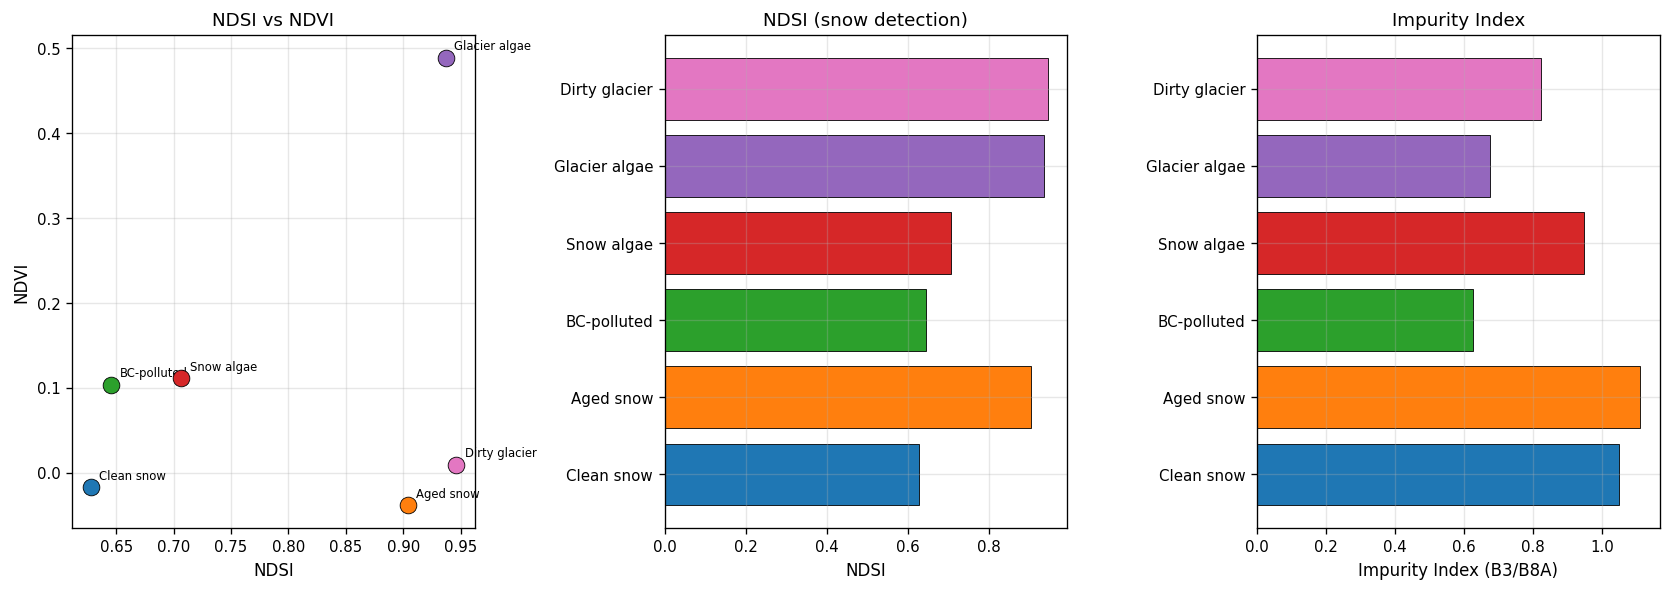

In [7]:
# --- Section 5: Spectral indices ---

def compute_s2_bands(spectrum):
    """Convolve a spectrum into S2 bands."""
    return {n: flux_weighted_band(spectrum, _FLX_SOLAR, tophat_srf(WVL, c, h))
            for n, (c, h) in S2_BANDS.items()}

def ndsi(bands):
    return (bands["B3"] - bands["B11"]) / (bands["B3"] + bands["B11"])

def ndvi(bands):
    return (bands["B8"] - bands["B4"]) / (bands["B8"] + bands["B4"])

def impurity_index(bands):
    return bands["B3"] / bands["B8A"]

# Generate scenarios using SSA
scenarios = {
    "Clean snow":     dict(ssa=50),
    "Aged snow":      dict(ssa=10),
    "BC-polluted":    dict(ssa=15, black_carbon=200),
    "Snow algae":     dict(ssa=30, snow_algae=10000),
    "Glacier algae":  dict(ssa=3, glacier_algae=20000),
    "Dirty glacier":  dict(ssa=1.5, black_carbon=100, dust=5000),
}

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

ndsi_vals, ndvi_vals, ii_vals, labels = [], [], [], []
colors_sc = plt.cm.tab10(np.linspace(0, 0.6, len(scenarios)))

for (name, params), color in zip(scenarios.items(), colors_sc):
    b = compute_s2_bands(toy_spectrum(**params))
    ndsi_vals.append(ndsi(b))
    ndvi_vals.append(ndvi(b))
    ii_vals.append(impurity_index(b))
    labels.append(name)

# NDSI vs NDVI scatter
for i, (label, color) in enumerate(zip(labels, colors_sc)):
    axes[0].scatter(ndsi_vals[i], ndvi_vals[i], c=[color], s=100,
                    edgecolors="k", linewidth=0.5, zorder=3)
    axes[0].annotate(label, (ndsi_vals[i], ndvi_vals[i]),
                     fontsize=7, xytext=(5, 5), textcoords="offset points")
axes[0].set(xlabel="NDSI", ylabel="NDVI", title="NDSI vs NDVI")

# Index bar charts
x = np.arange(len(labels))
axes[1].barh(x, ndsi_vals, color=colors_sc, edgecolor="k", linewidth=0.5)
axes[1].set(xlabel="NDSI", yticks=x, yticklabels=labels,
            title="NDSI (snow detection)")

axes[2].barh(x, ii_vals, color=colors_sc, edgecolor="k", linewidth=0.5)
axes[2].set(xlabel="Impurity Index (B3/B8A)", yticks=x, yticklabels=labels,
            title="Impurity Index")

fig.tight_layout()
plt.show()

**Figure 5.** Spectral indices for six surface scenarios ranging from
clean snow to a dirty glacier.  *(Left)* NDSI vs NDVI scatter plot:
clean/aged snow clusters at high NDSI and near-zero NDVI, while
biological impurities (algae) push NDVI positive and reduce NDSI.
*(Centre)* NDSI bar chart showing that all snow/ice surfaces exceed
0.4 (the standard snow-detection threshold) except the most heavily
polluted.  *(Right)* Impurity Index (B3 / B8A): clean surfaces are
near 1.0; increasing visible-band darkening from impurities drives
the index below 1.0.

### Key observations

1. **NDSI separates snow from non-snow** effectively (clean/aged snow have
   NDSI > 0.6; heavily impure surfaces drop below 0.5).
2. **NDVI detects biological activity** — snow algae and glacier algae push
   NDVI positive.
3. **Impurity Index tracks visible darkening** — clean snow ≈ 1.0, polluted
   surfaces < 1.0.
4. **Indices are ambiguous:** BC-polluted snow and glacier algae can give
   similar NDSI values despite very different causes.

> **BioSNICAR connection** — Sentinel-2 indices (NDSI, NDVI, II) are
> computed in `biosnicar/bands/platforms/sentinel2.py:42–51` and stored
> as named attributes on the `BandResult` object.  Access them via
> `result.NDSI`, `result.NDVI`, `result.II`.

---

# Act II — Bridging Spectra and Bands

Act II connects the forward model to satellite bands and explores how
much information survives the spectral-to-band compression.

## Section 6: The Forward Problem in Band Space

The **forward problem** maps physical parameters to observables.  In remote
sensing, there are two levels:

1. **Spectral forward problem:** Parameters → 480-band albedo.
2. **Band forward problem:** 480-band albedo → N satellite bands.

The complete pipeline is:

$$\text{(rds, ρ, BC, algae, ...)} \xrightarrow{\text{forward model}} \alpha(\lambda) \xrightarrow{\texttt{to\_platform()}} (B_1, B_2, \ldots, B_N)$$

At each arrow, information is lost: the forward model is many-to-one
(different parameter combinations can give similar spectra), and band
convolution compresses 480 values into N ≪ 480.

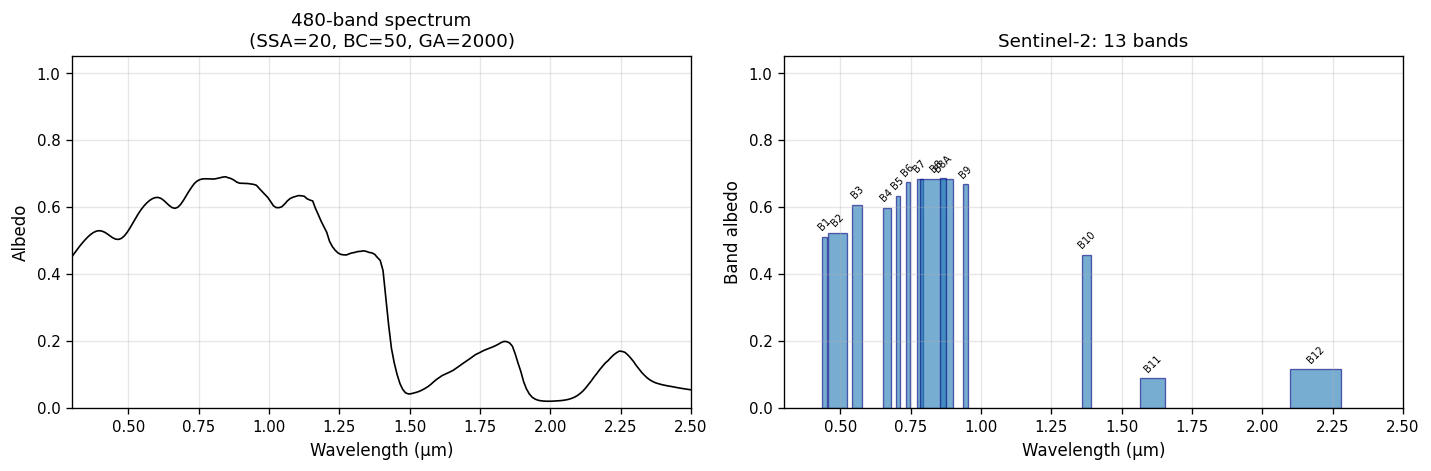

Information compression: 480 spectral values → 13 bands
Compression ratio: 37:1


In [8]:
# --- Section 6: Forward problem in band space ---

params = dict(ssa=20, black_carbon=50, glacier_algae=2000)
spectrum = toy_spectrum(**params)

# Convolve to S2 bands
s2 = compute_s2_bands(spectrum)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Left: full spectrum
ax1.plot(WVL, spectrum, "k-", lw=1)
ax1.set(xlabel="Wavelength (µm)", ylabel="Albedo", xlim=(0.3, 2.5),
        ylim=(0, 1.05), title=f"480-band spectrum\n(SSA={params['ssa']}, BC={params['black_carbon']}, GA={params['glacier_algae']})")

# Right: S2 band bars
centres = [c for c, h in S2_BANDS.values()]
widths = [h * 2 for c, h in S2_BANDS.values()]
vals = list(s2.values())
ax2.bar(centres, vals, width=widths, alpha=0.6, edgecolor="navy", linewidth=0.8)
for c, v, n in zip(centres, vals, s2.keys()):
    ax2.text(c, v + 0.02, n, ha="center", fontsize=6, rotation=45)
ax2.set(xlabel="Wavelength (µm)", ylabel="Band albedo", xlim=(0.3, 2.5),
        ylim=(0, 1.05), title="Sentinel-2: 13 bands")

fig.tight_layout()
plt.show()

print(f"Information compression: {N_WVL} spectral values → {len(s2)} bands")
print(f"Compression ratio: {N_WVL / len(s2):.0f}:1")

**Figure 6.** The forward-problem pipeline visualised for a moderately
impure glacier surface (SSA = 8, BC = 20, GA = 2000).  *(Left)* The
full 480-band spectral albedo showing the characteristic ice absorption
features and visible-band darkening from impurities.  *(Right)* The
same spectrum compressed to Sentinel-2's 13 bands, each bar positioned
at the band centre wavelength.  The compression ratio is 37:1 — the
13 band values must encode all retrievable information about the
surface.

## Section 7: Information Content

Not all 13 Sentinel-2 bands are independent — adjacent bands are correlated
because the underlying spectrum changes smoothly.  **Principal Component
Analysis (PCA)** reveals how many independent dimensions of information
the bands actually carry.

The number of PCA components needed to explain >99% of variance gives the
**effective degrees of freedom (DOF)** — roughly how many parameters we
can hope to retrieve from the band data.

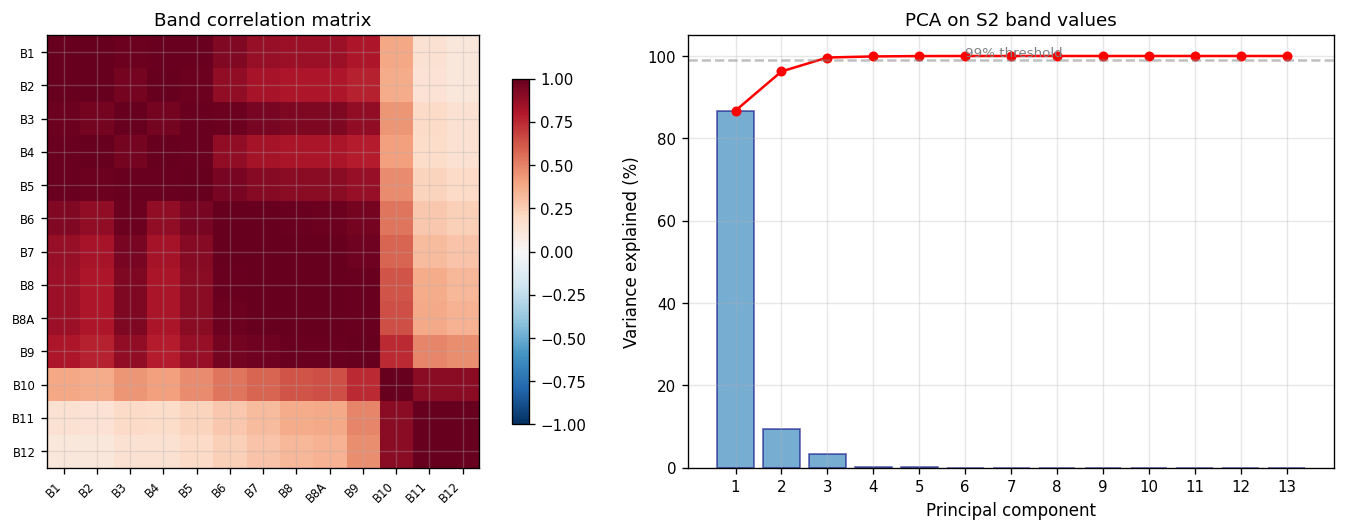


Components for 99% variance: 3
Effective DOF ≈ 3 — this limits how many params we can retrieve.


In [9]:
# --- Section 7: Information content ---

# Generate a library of band values from diverse surfaces
n_samples = 2000
ssa_arr = np.random.uniform(1, 60, n_samples)
bc_arr = np.random.exponential(50, n_samples)
ga_arr = np.random.exponential(3000, n_samples)
solzen_arr = np.random.uniform(20, 70, n_samples)

band_matrix = np.zeros((n_samples, len(S2_BANDS)))
for i in range(n_samples):
    s = toy_spectrum(ssa=ssa_arr[i], black_carbon=bc_arr[i],
                     glacier_algae=ga_arr[i], solzen=solzen_arr[i])
    bands = compute_s2_bands(s)
    band_matrix[i] = list(bands.values())

# PCA
band_centred = band_matrix - band_matrix.mean(axis=0)
cov = np.cov(band_centred.T)
eigenvalues = np.linalg.eigvalsh(cov)[::-1]
explained = eigenvalues / eigenvalues.sum()
cumulative = np.cumsum(explained)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: band correlation heatmap
corr = np.corrcoef(band_matrix.T)
band_names = list(S2_BANDS.keys())
im = ax1.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
ax1.set(xticks=range(13), xticklabels=band_names,
        yticks=range(13), yticklabels=band_names,
        title="Band correlation matrix")
plt.setp(ax1.get_xticklabels(), rotation=45, ha="right", fontsize=7)
plt.setp(ax1.get_yticklabels(), fontsize=7)
fig.colorbar(im, ax=ax1, shrink=0.8)

# Right: PCA variance explained
ax2.bar(range(1, 14), explained * 100, alpha=0.6, edgecolor="navy")
ax2.plot(range(1, 14), cumulative * 100, "ro-", markersize=5)
ax2.axhline(99, color="gray", ls="--", alpha=0.5)
ax2.set(xlabel="Principal component", ylabel="Variance explained (%)",
        title="PCA on S2 band values", xticks=range(1, 14))
ax2.text(6, 100, "99% threshold", fontsize=8, color="gray")

fig.tight_layout()
plt.show()

n_99 = int(np.searchsorted(cumulative, 0.99)) + 1
print(f"\nComponents for 99% variance: {n_99}")
print(f"Effective DOF ≈ {n_99} — this limits how many params we can retrieve.")

**Figure 7.** Information content of Sentinel-2's 13 bands, assessed
over 2000 randomly generated snow/ice surfaces.  *(Left)* Band-to-band
correlation matrix: visible bands (B1–B4) are highly correlated (red),
while SWIR bands (B11, B12) add independent information (blue/white
off-diagonal).  *(Right)* PCA variance explained: ~3 principal
components capture > 99% of the total variance (red curve), indicating
that the 13 bands carry only ~3–4 independent degrees of freedom.
This sets the practical ceiling for multi-parameter retrieval.

### Key observations

1. **Visible bands (B1–B4) are highly correlated** — they largely measure
   the same thing (visible albedo, affected by impurities).
2. **NIR and SWIR bands add independent information** about grain size
   and ice structure.
3. **~3–4 PCA components capture >99% of variance** — so from 13 bands
   we get ~3–4 independent pieces of information.  This sets the practical
   ceiling for multi-parameter retrieval (Section 22).

## Section 8: Multi-Platform Comparison

The same surface looks different through different satellites because each
one samples different parts of the spectrum with different bandwidths.
Understanding these differences is critical for multi-platform studies.

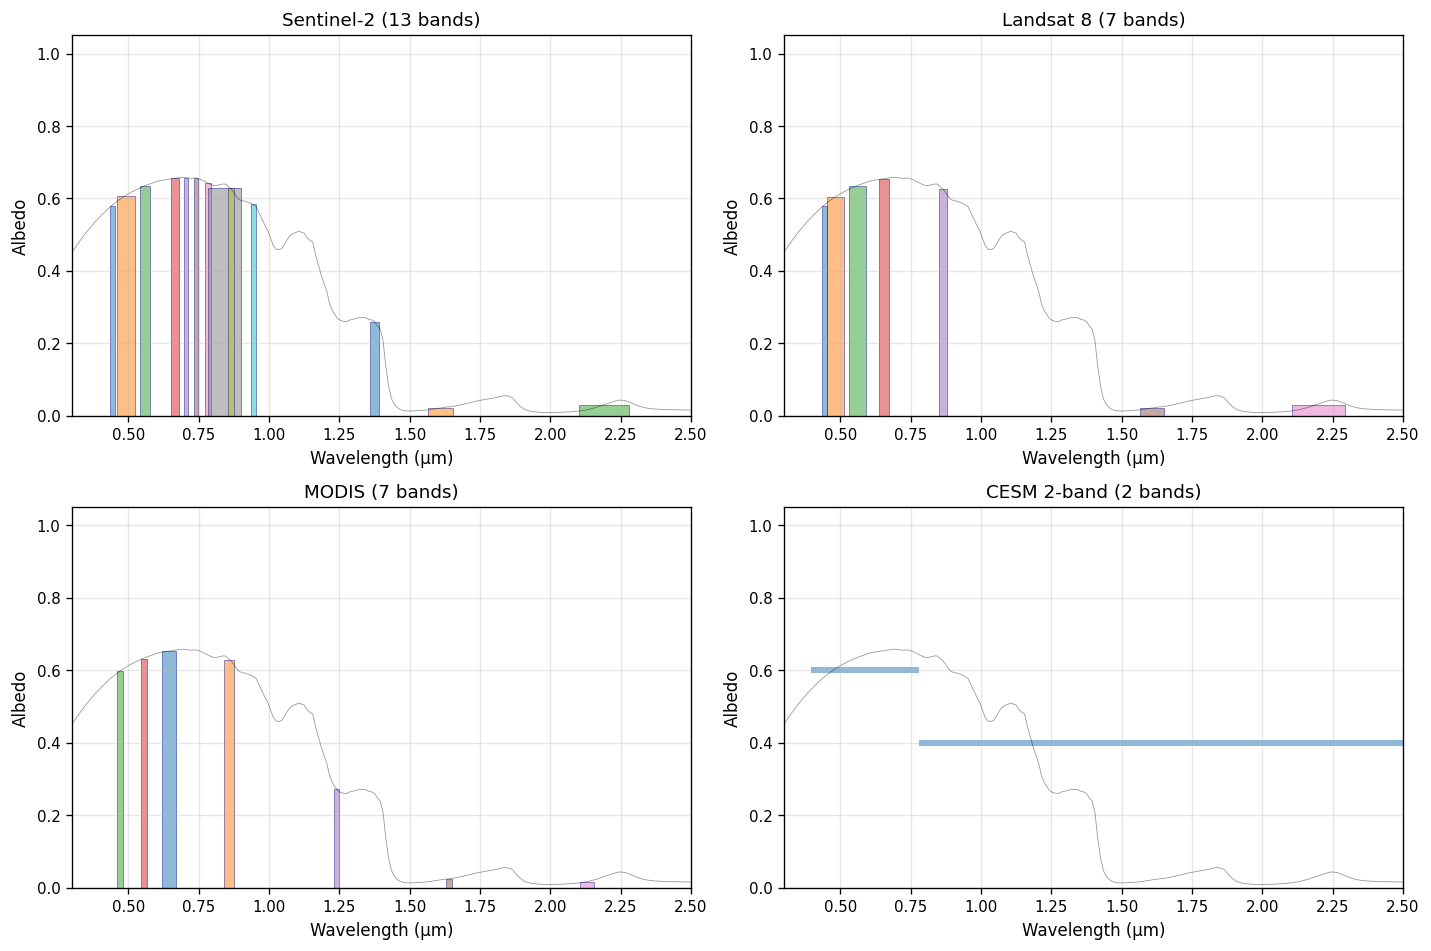

In [10]:
# --- Section 8: Multi-platform comparison ---

# Define simplified platform band sets
# Landsat 8 OLI: 7 bands (from biosnicar/bands/platforms/landsat8.py)
PLATFORMS = {
    "Sentinel-2": S2_BANDS,
    "Landsat 8": {
        "B1": (0.443, 0.008), "B2": (0.482, 0.030), "B3": (0.561, 0.029),
        "B4": (0.655, 0.019), "B5": (0.865, 0.014), "B6": (1.609, 0.042),
        "B7": (2.201, 0.094),
    },
    "MODIS": {
        "B1": (0.645, 0.025), "B2": (0.858, 0.018), "B3": (0.469, 0.010),
        "B4": (0.555, 0.010), "B5": (1.240, 0.010), "B6": (1.640, 0.012),
        "B7": (2.130, 0.025),
    },
    "CESM 2-band": {"VIS": None, "NIR": None},
}

spectrum = toy_spectrum(ssa=5, black_carbon=50)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for idx, (pname, bands) in enumerate(PLATFORMS.items()):
    ax = axes[idx]
    ax.plot(WVL, spectrum, "k-", lw=0.5, alpha=0.4, label="480-band")

    if pname == "CESM 2-band":
        for name, (lo, hi) in CESM2_BANDS.items():
            val = interval_average(spectrum, _FLX_SOLAR, lo, hi)
            ax.axhspan(val - 0.008, val + 0.008,
                       xmin=(lo - 0.2) / 2.3, xmax=min((hi - 0.2) / 2.3, 1),
                       alpha=0.5, label=f"{name}: {val:.3f}")
    else:
        for name, (cen, hw) in bands.items():
            srf = tophat_srf(WVL, cen, hw)
            val = flux_weighted_band(spectrum, _FLX_SOLAR, srf)
            ax.bar(cen, val, width=hw * 2, alpha=0.5, edgecolor="navy", lw=0.5)

    ax.set(xlim=(0.3, 2.5), ylim=(0, 1.05), title=f"{pname} ({len(bands)} bands)")
    ax.set_xlabel("Wavelength (µm)")
    ax.set_ylabel("Albedo")

fig.tight_layout()
plt.show()

**Figure 8.** The same surface spectrum viewed through four platforms
with different band configurations.  Each panel overlays the 480-band
spectrum (grey) with the platform's band-averaged values.  The
comparison illustrates how spectral resolution and coverage vary:
Sentinel-2 and Landsat 8 extend into the SWIR (critical for SSA
retrieval), MODIS provides daily global coverage with 7 land bands,
and CESM 2-band reduces everything to a VIS/NIR split for climate
energy budgets.

## Section 9: The Three `to_platform()` Entry Points

BioSNICAR provides three equivalent ways to convert spectra to bands,
depending on your workflow:

| Entry point | When to use |
|-------------|------------|
| `biosnicar.to_platform(albedo, "sentinel2", flx_slr)` | Standalone function — works with any albedo array |
| `outputs.to_platform("sentinel2")` | After `run_model()` — uses stored albedo and flux |
| `sweep_result.to_platform("sentinel2")` | After `sweep()` — batch-converts all spectra |

All three return a `BandResult` object with named band attributes (`.B1`,
`.B2`, ...) and index attributes (`.NDSI`, `.NDVI`, `.II`).

```python
# Example usage (requires biosnicar):
result = biosnicar.to_platform(albedo, "sentinel2", flx_slr=flux)
print(result.B3)     # Green band albedo
print(result.NDSI)   # Normalised Difference Snow Index
print(result.as_dict())  # All bands + indices as a dictionary
```

> **BioSNICAR connection** — The three entry points are:
> `biosnicar/bands/__init__.py:69` (`to_platform()`),
> `Outputs.to_platform()` in `biosnicar/classes/outputs.py`, and
> `SweepResult.to_platform()` in `biosnicar/drivers/sweep.py`.
> The `BandResult` container is defined at
> `biosnicar/bands/__init__.py:18`.

In [11]:
# --- Section 9: Toy to_platform() API ---

class ToyBandResult:
    """Simplified BandResult — mirrors biosnicar/bands/__init__.py:18."""
    def __init__(self, platform):
        self.platform = platform
        self._bands = {}
        self._indices = {}

    def _set_band(self, name, value):
        self._bands[name] = value
        setattr(self, name, value)

    def _set_index(self, name, value):
        self._indices[name] = value
        setattr(self, name, value)

    @property
    def band_names(self):
        return list(self._bands.keys())

    @property
    def index_names(self):
        return list(self._indices.keys())

    def as_dict(self):
        return {**self._bands, **self._indices}

def toy_to_platform(albedo, platform, flx_slr=None):
    """Toy version of biosnicar.to_platform()."""
    if flx_slr is None:
        flx_slr = _FLX_SOLAR

    if platform == "sentinel2":
        r = ToyBandResult("sentinel2")
        for name, (cen, hw) in S2_BANDS.items():
            srf = tophat_srf(WVL, cen, hw)
            r._set_band(name, flux_weighted_band(albedo, flx_slr, srf))
        # Indices (matches sentinel2.py:42-51)
        denom = r.B3 + r.B11
        r._set_index("NDSI", (r.B3 - r.B11) / denom if denom != 0 else float("nan"))
        denom = r.B8 + r.B4
        r._set_index("NDVI", (r.B8 - r.B4) / denom if denom != 0 else float("nan"))
        r._set_index("II", r.B3 / r.B8A if r.B8A != 0 else float("nan"))
        return r

    elif platform == "cesm2band":
        r = ToyBandResult("cesm2band")
        r._set_band("VIS", interval_average(albedo, flx_slr, 0.3, 0.7))
        r._set_band("NIR", interval_average(albedo, flx_slr, 0.7, 5.0))
        return r

    raise ValueError(f"Unknown platform: {platform}")

# Demo
spectrum = toy_spectrum(ssa=15, black_carbon=30)
result = toy_to_platform(spectrum, "sentinel2")

print(f"Platform: {result.platform}")
print(f"Bands: {result.band_names}")
print(f"Indices: {result.index_names}")
print(f"\nB3 (Green): {result.B3:.4f}")
print(f"B11 (SWIR): {result.B11:.4f}")
print(f"NDSI: {result.NDSI:.4f}")
print(f"NDVI: {result.NDVI:.4f}")
print(f"II:   {result.II:.4f}")

Platform: sentinel2
Bands: ['B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B9', 'B10', 'B11', 'B12']
Indices: ['NDSI', 'NDVI', 'II']

B3 (Green): 0.7434
B11 (SWIR): 0.0678
NDSI: 0.8328
NDVI: -0.0110
II:   1.0025


---

# Act III — The Inverse Problem in Practice

The **inverse problem** is: given satellite observations, what are the
surface properties?  This is harder than the forward problem because
the mapping is not one-to-one.  Act III builds the mathematical tools
for inversion.

## Section 10: The Inverse Problem

The **forward problem** is well-posed: given parameters, compute the
spectrum.  The **inverse problem** asks: given an observed spectrum (or
band values), what parameters produced it?

The standard approach is **optimisation**: find parameters that minimise
a **cost function** measuring the mismatch between model and observation:

$$J(\mathbf{x}) = \sum_i \left(\frac{\alpha^{\text{obs}}_i - \alpha^{\text{model}}_i(\mathbf{x})}{\sigma_i}\right)^2$$

where $\sigma_i$ is the measurement uncertainty in band $i$.

The challenge: the cost landscape may be **flat** (parameters to which the
spectrum is insensitive), **multi-modal** (multiple parameter sets giving
equally good fits), or **degenerate** (different parameters trading off
against each other).

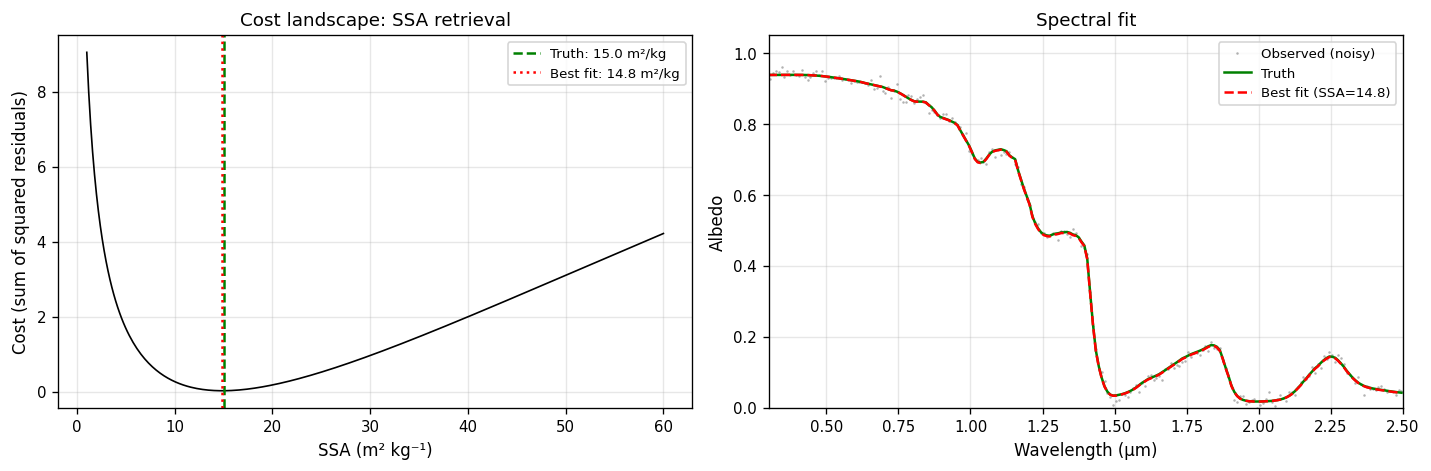

True SSA:    15.0 m²/kg
Retrieved:   14.8 m²/kg
Error:       0.2 m²/kg (1.2%)


In [12]:
# --- Section 10: Cost function basics ---

# Truth: SSA=15, observe with noise
true_ssa = 15.0
true_spectrum = toy_spectrum(ssa=true_ssa)
noise = np.random.normal(0, 0.01, N_WVL)
observed = np.clip(true_spectrum + noise, 0, 1)

# Cost vs SSA (1D)
ssa_range = np.linspace(1, 60, 300)
costs = []
for s in ssa_range:
    model = toy_spectrum(ssa=s)
    cost = np.sum((observed[:230] - model[:230])**2)  # VIS+NIR only
    costs.append(cost)
costs = np.array(costs)

# Best fit
best_ssa = ssa_range[np.argmin(costs)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Left: cost vs parameter
ax1.plot(ssa_range, costs, "k-", lw=1)
ax1.axvline(true_ssa, color="green", ls="--", label=f"Truth: {true_ssa} m²/kg")
ax1.axvline(best_ssa, color="red", ls=":", label=f"Best fit: {best_ssa:.1f} m²/kg")
ax1.set(xlabel="SSA (m² kg⁻¹)", ylabel="Cost (sum of squared residuals)",
        title="Cost landscape: SSA retrieval")
ax1.legend()

# Right: best fit vs observation
ax2.plot(WVL[:230], observed[:230], "k.", markersize=1, alpha=0.3, label="Observed (noisy)")
ax2.plot(WVL[:230], true_spectrum[:230], "g-", lw=1.5, label="Truth")
ax2.plot(WVL[:230], toy_spectrum(ssa=best_ssa)[:230], "r--", lw=1.5,
         label=f"Best fit (SSA={best_ssa:.1f})")
ax2.set(xlabel="Wavelength (µm)", ylabel="Albedo", xlim=(0.3, 2.5), ylim=(0, 1.05),
        title="Spectral fit")
ax2.legend()

fig.tight_layout()
plt.show()

print(f"True SSA:    {true_ssa} m²/kg")
print(f"Retrieved:   {best_ssa:.1f} m²/kg")
print(f"Error:       {abs(best_ssa - true_ssa):.1f} m²/kg ({abs(best_ssa - true_ssa)/true_ssa*100:.1f}%)")

**Figure 9.** A single-parameter retrieval of SSA from a noisy 480-band
observation.  *(Left)* Cost function (sum of squared residuals) as a
function of SSA, showing a well-defined minimum near the true value
(green dashed line).  The parabolic shape near the minimum indicates
the problem is well-posed.  *(Right)* Spectral comparison: the noisy
observation (grey dots), the true spectrum (green), and the best-fit
model (red dashed) are nearly indistinguishable, confirming a
successful retrieval.

> **BioSNICAR connection** — The cost function is implemented in
> `biosnicar/inverse/cost.py:19` (`spectral_cost()`) for 480-band mode
> and `biosnicar/inverse/cost.py:76` (`band_cost()`) for satellite-band
> mode.  Both compute chi-squared with optional uncertainty weighting.
> The `retrieve()` function (`biosnicar/inverse/optimize.py:71`) wraps
> the optimiser and dispatches to the appropriate cost function.

## Section 11: Parameter Degeneracy — Why SSA Is the Right Target

Some parameters produce **degenerate** spectral signatures — different
combinations give nearly identical spectra.  The classic example in snow
remote sensing is the **grain radius – density trade-off**.

The **specific surface area** can be written as:

$$\text{SSA} = \frac{3}{r_{\text{eff}} \cdot \rho}$$

where $\rho$ is the bulk density of the medium (kg m⁻³).  For solid ice
($\rho = 917$) this simplifies to $3 / (r \cdot 917)$.  But for porous
snow or bubbly glacier ice, **both grain radius and bulk density matter**:
the same SSA can arise from small grains in dense ice *or* larger grains
in less dense snow.

If you try to retrieve rds and ρ **jointly**, the optimiser sees a valley
in cost space along constant-SSA hyperbolas — it can trade rds against ρ
without improving the fit.  The result: both parameters are poorly
constrained, even though their combination (SSA) is well-determined.

The solution: **retrieve SSA directly**.

/tmp/ipykernel_2944896/2775239733.py:85: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(data, labels=labels, patch_artist=True, whis=(5, 95))


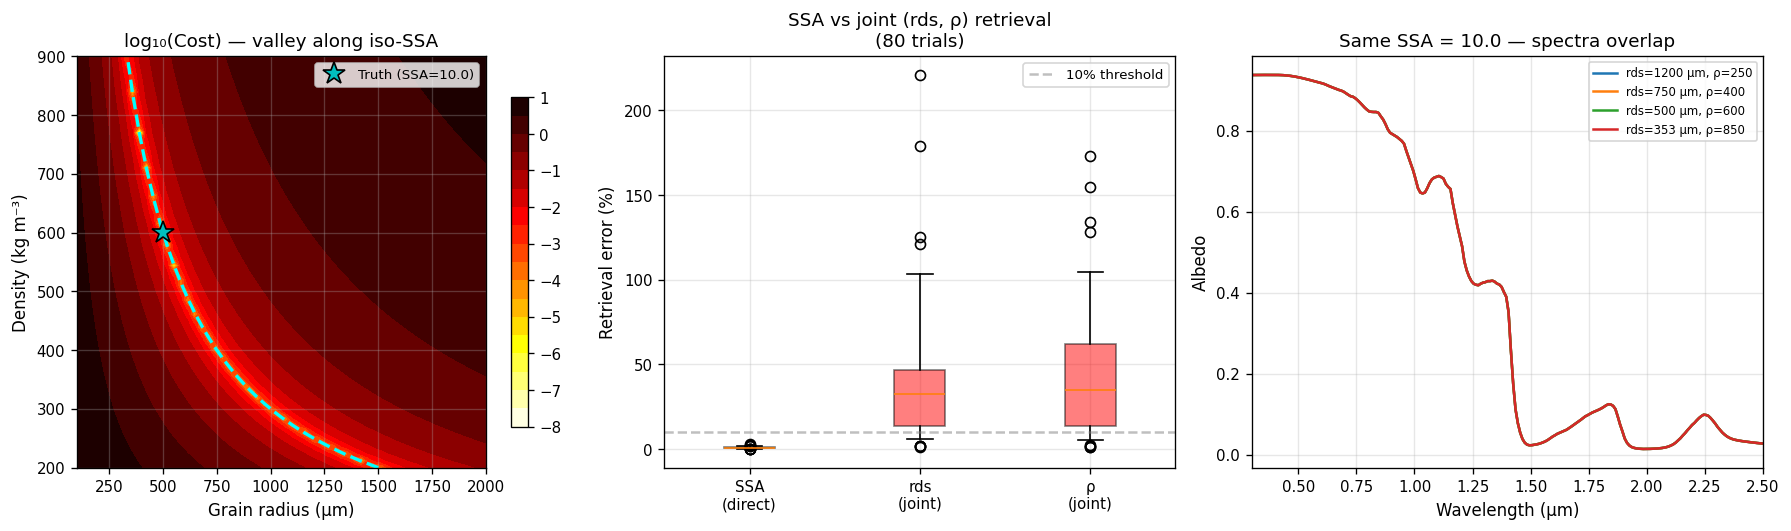

Median retrieval errors:
  SSA (direct, 1 param):     0.6%
  rds (joint with ρ):       32.3%
  ρ   (joint with rds):     34.9%


In [13]:
# --- Section 11: rds-rho degeneracy → why SSA works ---

# For this section we create a forward model where the effective SSA
# depends on BOTH grain radius and bulk density:
#   SSA = 3 / (r_m * rho)
# Different (rds, rho) pairs with the same SSA give the same spectrum.

def toy_spectrum_rds_rho(rds, rho, **kwargs):
    """Forward model parameterised by (rds, rho) separately.

    SSA = 3 / (r_eff * rho), so spectra depend on the product r*rho.
    Different (rds, rho) pairs with the same SSA are degenerate.
    """
    r_m = rds * 1e-6
    ssa_eff = 3.0 / (r_m * rho)
    return toy_spectrum(ssa=np.clip(ssa_eff, 0.5, 65), **kwargs)

# --- Truth ---
true_rds, true_rho = 500, 600
true_ssa = 3.0 / (true_rds * 1e-6 * true_rho)  # = 10.0
true_spec = toy_spectrum_rds_rho(true_rds, true_rho)

# --- Panel 1: Cost surface in (rds, rho) space ---
rds_grid = np.linspace(100, 2000, 60)
rho_grid = np.linspace(200, 900, 60)
RDS, RHO = np.meshgrid(rds_grid, rho_grid)
SSA_GRID = 3.0 / (RDS * 1e-6 * RHO)

COST = np.zeros_like(RDS)
for i in range(len(rho_grid)):
    for j in range(len(rds_grid)):
        model = toy_spectrum_rds_rho(RDS[i, j], RHO[i, j])
        COST[i, j] = np.sum((true_spec[:230] - model[:230])**2)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4.5))

# Panel 1: cost surface with iso-SSA contour
im = ax1.contourf(rds_grid, rho_grid, np.log10(COST + 1e-12), levels=20, cmap="hot_r")
ax1.contour(rds_grid, rho_grid, SSA_GRID, levels=[true_ssa],
            colors="cyan", linewidths=2, linestyles="--")
ax1.plot(true_rds, true_rho, "c*", markersize=14, markeredgecolor="k",
         label=f"Truth (SSA={true_ssa:.1f})")
ax1.set(xlabel="Grain radius (µm)", ylabel="Density (kg m⁻³)",
        title="log₁₀(Cost) — valley along iso-SSA")
ax1.legend(fontsize=8, loc="upper right")
fig.colorbar(im, ax=ax1, shrink=0.8)

# --- Panel 2: Retrieval comparison ---
n_trials = 80
np.random.seed(123)
# Generate diverse true (rds, rho) pairs
true_rds_arr = np.random.uniform(200, 1500, n_trials)
true_rho_arr = np.random.uniform(250, 850, n_trials)
true_ssa_arr = 3.0 / (true_rds_arr * 1e-6 * true_rho_arr)

ssa_errors, joint_rds_errors, joint_rho_errors = [], [], []

for k in range(n_trials):
    tr, td = true_rds_arr[k], true_rho_arr[k]
    ts = true_ssa_arr[k]
    obs = np.clip(toy_spectrum_rds_rho(tr, td) + np.random.normal(0, 0.01, N_WVL), 0, 1)

    # (a) Retrieve SSA directly — 1 parameter
    def cost_s(x):
        return np.sum((obs[:230] - toy_spectrum(ssa=x[0])[:230])**2)
    res = optimize.minimize(cost_s, [15], bounds=[(0.5, 65)], method="L-BFGS-B")
    ssa_errors.append(abs(res.x[0] - ts) / ts * 100)

    # (b) Retrieve (rds, rho) jointly — 2 parameters
    def cost_joint(x):
        return np.sum((obs[:230] - toy_spectrum_rds_rho(x[0], x[1])[:230])**2)
    # Try multiple starting points and take best
    best_cost, best_x = np.inf, None
    for r0, d0 in [(300, 400), (700, 600), (1000, 300), (500, 800)]:
        res_j = optimize.minimize(cost_joint, [r0, d0],
                                  bounds=[(50, 3000), (200, 900)], method="L-BFGS-B")
        if res_j.fun < best_cost:
            best_cost = res_j.fun
            best_x = res_j.x
    joint_rds_errors.append(abs(best_x[0] - tr) / tr * 100)
    joint_rho_errors.append(abs(best_x[1] - td) / td * 100)

data = [ssa_errors, joint_rds_errors, joint_rho_errors]
labels = ["SSA\n(direct)", "rds\n(joint)", "ρ\n(joint)"]
bp = ax2.boxplot(data, labels=labels, patch_artist=True, whis=(5, 95))
colours = ["green", "red", "red"]
for box, col in zip(bp["boxes"], colours):
    box.set_facecolor(col)
    box.set_alpha(0.5)
ax2.axhline(10, color="gray", ls="--", alpha=0.5, label="10% threshold")
ax2.set(ylabel="Retrieval error (%)",
        title=f"SSA vs joint (rds, ρ) retrieval\n({n_trials} trials)")
ax2.legend(fontsize=8)

# --- Panel 3: Iso-SSA spectra (different rds,rho, same SSA) ---
iso_ssa = 10.0
for rho_val in [250, 400, 600, 850]:
    r_m = 3.0 / (iso_ssa * rho_val)  # metres
    rds_val = r_m * 1e6  # µm
    if 50 < rds_val < 5000:
        s = toy_spectrum_rds_rho(rds_val, rho_val)
        ax3.plot(WVL[:230], s[:230],
                 label=f"rds={rds_val:.0f} µm, ρ={rho_val}")
ax3.set(xlabel="Wavelength (µm)", ylabel="Albedo", xlim=(0.3, 2.5),
        title=f"Same SSA = {iso_ssa} — spectra overlap")
ax3.legend(fontsize=7)

fig.tight_layout()
plt.show()

print(f"Median retrieval errors:")
print(f"  SSA (direct, 1 param):   {np.median(ssa_errors):5.1f}%")
print(f"  rds (joint with ρ):      {np.median(joint_rds_errors):5.1f}%")
print(f"  ρ   (joint with rds):    {np.median(joint_rho_errors):5.1f}%")

**Figure 10.** Why SSA, not (rds, ρ), should be the retrieval target.
*(Left)* Cost surface in (grain radius, density) space for a fixed
observation: the deep valley (dark colours) runs along the iso-SSA
hyperbola (cyan dashed line) where SSA = 3/(r·ρ) is constant, meaning
any (rds, ρ) pair on this curve fits the data equally well.  *(Centre)*
Box plot comparing retrieval errors over 80 random trials: retrieving
SSA directly (green, 1 parameter) gives consistently low errors, while
jointly retrieving rds and ρ (red, 2 parameters) produces large errors
on both because the optimiser slides along the cost valley.  *(Right)*
Spectra for four (rds, ρ) pairs that all give SSA = 10 — they are
identical, confirming the degeneracy.

### Key observations

1. **Iso-SSA hyperbolas** define the valley in (rds, ρ) cost space — any
   point on the same curve gives an identical spectrum.
2. **Joint (rds, ρ) retrieval** produces large errors on both parameters
   because they trade off against each other.
3. **SSA retrieval is well-constrained** — a single parameter with a
   clear, parabolic cost minimum.

**Best practice:** Always retrieve SSA, not grain radius.  If you need rds,
derive it from SSA using ancillary density information.

> **BioSNICAR connection** — The `RetrievalResult` class
> (`biosnicar/inverse/result.py:72`) automatically computes SSA from
> retrieved parameters using `_compute_ssa()` (line 16).  The emulator's
> `_make_ssa_emulator_fn()` in `optimize.py` builds a dedicated SSA
> forward function that bypasses the degeneracy entirely.

## Section 12: Log-Space Optimisation and Impurity Sensitivity

Impurity concentrations span orders of magnitude (0.1–10,000 ppb for BC).
Optimising in **linear space** wastes steps: a change from 1 to 2 ppb
matters much more than 5001 to 5002.  The solution is to optimise in
**log space**:

$$x_{\text{opt}} = \log_{10}(x + 1)$$

The `+1` avoids the singularity at $x = 0$.  This transform compresses the
dynamic range and makes the cost surface more symmetric.

A second challenge: not all impurities are equally detectable.  **Dust has
very low spectral sensitivity** — its spectrum overlaps with grain-size
effects, making it the hardest impurity to retrieve.

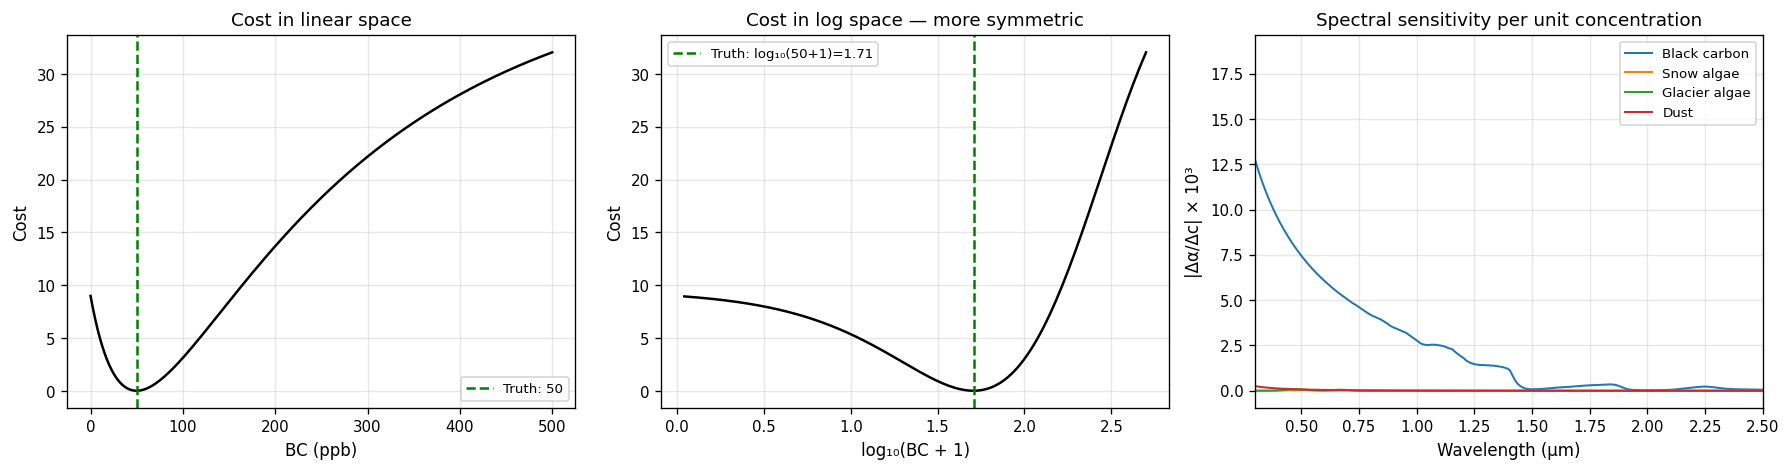


Spectral sensitivity (integrated |Δα/Δc|):
  Black carbon    : 0.6841
  Snow algae      : 0.0007
  Glacier algae   : 0.0015
  Dust            : 0.0087


In [14]:
# --- Section 12: Log-space optimisation ---

# 1D cost surface for BC concentration: linear vs log space
true_bc = 50
true_spec = toy_spectrum(ssa=15, black_carbon=true_bc)
noise = np.random.normal(0, 0.008, N_WVL)
observed = np.clip(true_spec + noise, 0, 1)

bc_linear = np.linspace(0, 500, 200)
bc_log = np.logspace(-1, np.log10(500), 200)

def cost_1d(bc_val):
    model = toy_spectrum(ssa=15, black_carbon=bc_val)
    return np.sum((observed[:230] - model[:230])**2)

cost_lin = np.array([cost_1d(b) for b in bc_linear])
cost_log = np.array([cost_1d(b) for b in bc_log])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Panel 1: Linear-space cost
axes[0].plot(bc_linear, cost_lin, "k-")
axes[0].axvline(true_bc, color="green", ls="--", label=f"Truth: {true_bc}")
axes[0].set(xlabel="BC (ppb)", ylabel="Cost",
            title="Cost in linear space")
axes[0].legend()

# Panel 2: Log-space cost
axes[1].plot(np.log10(bc_log + 1), cost_log, "k-")
axes[1].axvline(np.log10(true_bc + 1), color="green", ls="--",
                label=f"Truth: log₁₀({true_bc}+1)={np.log10(true_bc+1):.2f}")
axes[1].set(xlabel="log₁₀(BC + 1)", ylabel="Cost",
            title="Cost in log space — more symmetric")
axes[1].legend()

# Panel 3: Spectral sensitivity dα/dc for each impurity
delta = 10  # ppb or cells/mL
base = toy_spectrum(ssa=15)
sensitivities = {}
for imp_name, imp_key in [("Black carbon", "black_carbon"),
                            ("Snow algae", "snow_algae"),
                            ("Glacier algae", "glacier_algae"),
                            ("Dust", "dust")]:
    perturbed = toy_spectrum(ssa=15, **{imp_key: delta})
    sensitivities[imp_name] = np.abs(perturbed - base) / delta

for name, sens in sensitivities.items():
    axes[2].plot(WVL[:230], sens[:230] * 1000, label=name, lw=1.2)
axes[2].set(xlabel="Wavelength (µm)", ylabel="|Δα/Δc| × 10³",
            title="Spectral sensitivity per unit concentration",
            xlim=(0.3, 2.5))
axes[2].legend()

fig.tight_layout()
plt.show()

print("\nSpectral sensitivity (integrated |Δα/Δc|):")
for name, sens in sensitivities.items():
    print(f"  {name:16s}: {np.sum(sens[:230]):.4f}")

**Figure 11.** Log-space optimisation and impurity sensitivity.
*(Left)* Cost function vs BC concentration in linear space — the
landscape is highly asymmetric, steep near zero and flat at high
concentrations.  *(Centre)* The same cost function in log₁₀(x + 1)
space — the landscape is more symmetric, improving gradient-based
optimiser convergence.  *(Right)* Spectral sensitivity |Δα/Δc| per
unit concentration for four impurity types: black carbon and algae
produce strong, spectrally distinct signatures, while dust sensitivity
is an order of magnitude weaker and spectrally similar to grain-size
effects.

### Key observations

1. **Log-space cost surface is smoother** and more symmetric, giving
   gradient-based optimisers better convergence.
2. **Black carbon and algae have strong spectral signatures** —
   concentrated in specific wavelength regions.
3. **Dust has very weak sensitivity** — its spectral effect overlaps
   with grain-size changes, making it poorly constrained in all
   retrieval modes.

> **BioSNICAR connection** — `_LOG_SPACE_PARAMS` is defined at
> `biosnicar/inverse/optimize.py:32`:
> `{"black_carbon", "snow_algae", "glacier_algae", "dust", "ssa"}`.
> The `retrieve()` function automatically applies the log₁₀(x+1) transform
> for these parameters during optimisation.

## Section 13: Measurement Uncertainty and Regularisation

Three increasingly sophisticated cost functions:

1. **Unweighted:** $J = \sum (\alpha^{\text{obs}} - \alpha^{\text{model}})^2$
   — treats all bands equally.
2. **Weighted (chi-squared):** $J = \sum \left(\frac{\alpha^{\text{obs}} - \alpha^{\text{model}}}{\sigma}\right)^2$
   — down-weights noisy bands.
3. **Regularised:** $J = \chi^2 + \sum \frac{(x - x_{\text{prior}})^2}{\sigma_{\text{prior}}^2}$
   — pulls poorly constrained parameters toward prior values.

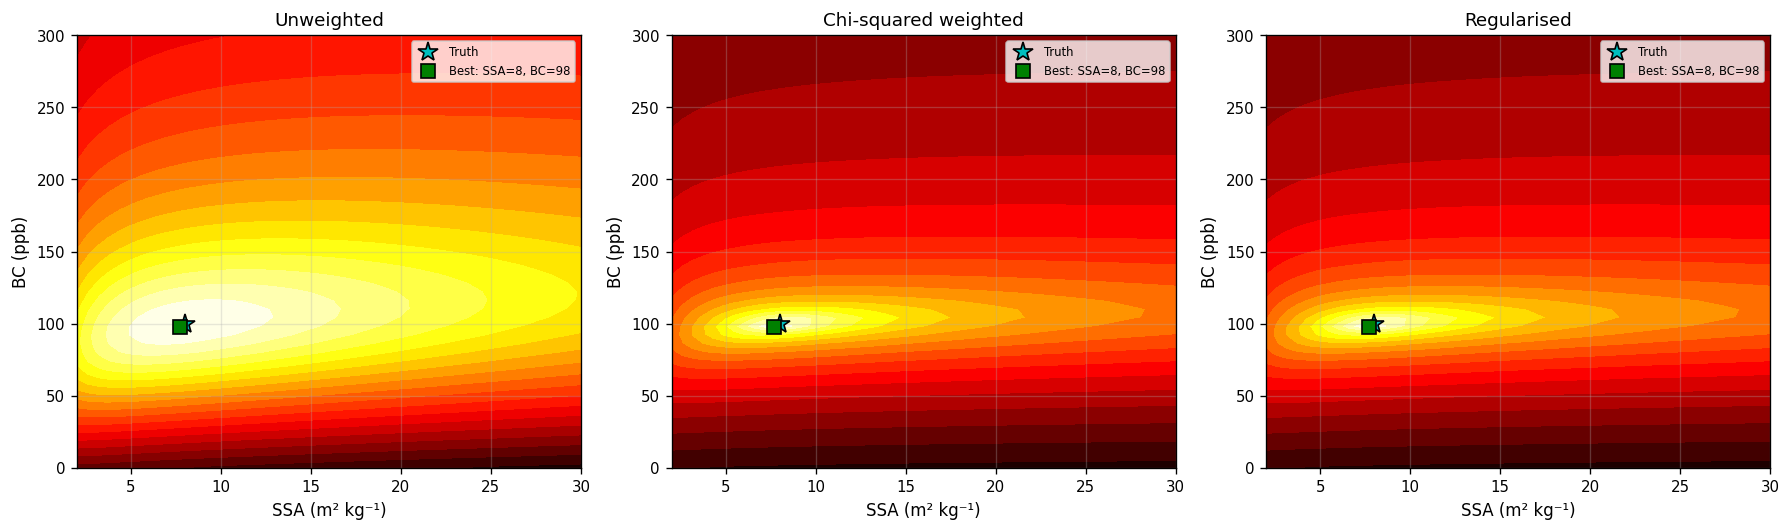

In [15]:
# --- Section 13: Uncertainty and regularisation ---

# Generate noisy observation with wavelength-dependent noise
true_params = dict(ssa=8, black_carbon=100)
true_spec = toy_spectrum(**true_params)

# Noise: higher in SWIR (lower signal), lower in VIS
sigma = 0.005 + 0.02 * (WVL / 2.5)**2
noise = np.random.normal(0, 1, N_WVL) * sigma
observed = np.clip(true_spec + noise, 0, 1)

# Three cost functions
def cost_unweighted(ssa, bc):
    model = toy_spectrum(ssa=ssa, black_carbon=bc)
    return np.sum((observed[:230] - model[:230])**2)

def cost_weighted(ssa, bc):
    model = toy_spectrum(ssa=ssa, black_carbon=bc)
    return np.sum(((observed[:230] - model[:230]) / sigma[:230])**2)

def cost_regularised(ssa, bc, prior_ssa=15, prior_bc=50, sig_ssa=10, sig_bc=100):
    model = toy_spectrum(ssa=ssa, black_carbon=bc)
    chi2 = np.sum(((observed[:230] - model[:230]) / sigma[:230])**2)
    reg = ((ssa - prior_ssa) / sig_ssa)**2 + ((bc - prior_bc) / sig_bc)**2
    return chi2 + reg

# Grid search for each
ssa_grid = np.linspace(2, 30, 50)
bc_grid = np.linspace(0, 300, 50)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
titles = ["Unweighted", "Chi-squared weighted", "Regularised"]
cost_fns = [cost_unweighted, cost_weighted, cost_regularised]

for ax, title, fn in zip(axes, titles, cost_fns):
    C = np.zeros((len(bc_grid), len(ssa_grid)))
    for i, bc in enumerate(bc_grid):
        for j, ssa in enumerate(ssa_grid):
            C[i, j] = fn(ssa, bc)
    im = ax.contourf(ssa_grid, bc_grid, np.log10(C + 1), levels=20, cmap="hot_r")
    ax.plot(true_params["ssa"], true_params["black_carbon"], "c*",
            markersize=12, markeredgecolor="k", label="Truth")
    # Find minimum
    ij = np.unravel_index(C.argmin(), C.shape)
    ax.plot(ssa_grid[ij[1]], bc_grid[ij[0]], "gs", markersize=8,
            markeredgecolor="k", label=f"Best: SSA={ssa_grid[ij[1]]:.0f}, BC={bc_grid[ij[0]]:.0f}")
    ax.set(xlabel="SSA (m² kg⁻¹)", ylabel="BC (ppb)", title=title)
    ax.legend(fontsize=7)

fig.tight_layout()
plt.show()

**Figure 12.** Three cost-function formulations for a 2-parameter
(SSA, BC) retrieval from a spectrum with wavelength-dependent noise.
Each panel shows contours of log₁₀(cost) in (SSA, BC) space, with
the truth (cyan star) and grid-search minimum (green square).
*(Left)* Unweighted sum of squares — the minimum is biased because
noisy SWIR bands dominate.  *(Centre)* Chi-squared weighting by 1/σ²
— the minimum tightens and moves closer to the truth.  *(Right)*
Regularised cost with Gaussian priors — the minimum is further
stabilised but pulled slightly toward the prior values.

### Key observations

1. **Unweighted cost** is dominated by noisy SWIR bands, pulling the
   estimate away from the truth.
2. **Chi-squared weighting** accounts for noise structure, giving a tighter
   constraint.
3. **Regularisation** adds a prior — useful when some parameters (e.g., dust)
   are poorly constrained by the data alone, but can bias the result toward
   the prior if the prior is wrong.

## Section 14: Wavelength Masking

Some spectral regions carry more information about certain parameters than
others.  **Wavelength masking** selects a subset of bands or wavelengths to:

1. **Focus on diagnostic regions** (e.g., NIR for grain size).
2. **Exclude atmospheric absorption bands** (water vapour at 1.4, 1.9 µm)
   where the surface signal is contaminated.
3. **Reduce computational cost** without sacrificing accuracy.

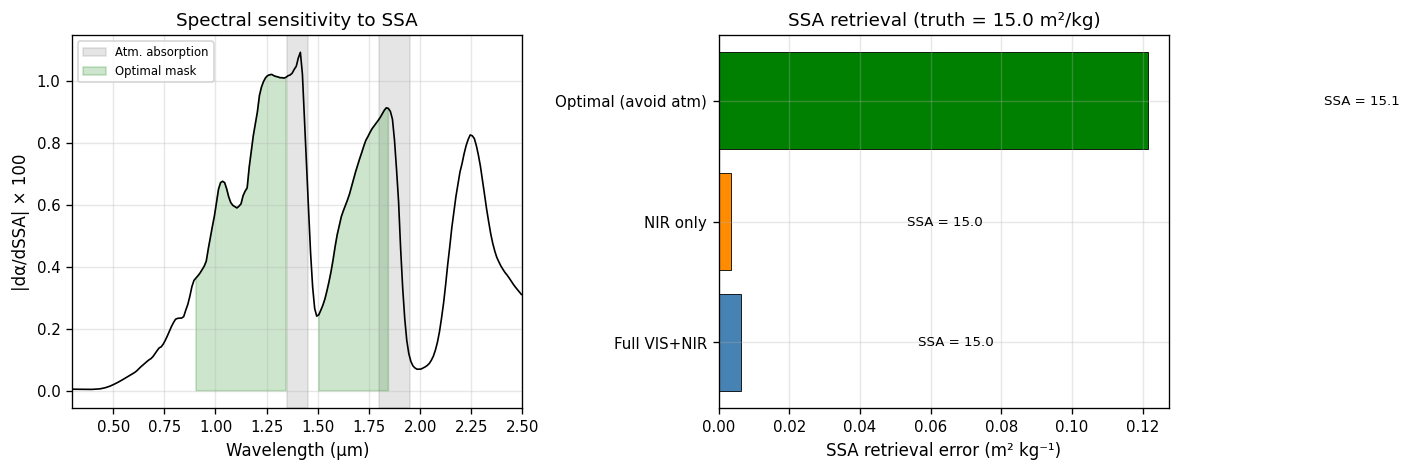

In [16]:
# --- Section 14: Wavelength masking ---

# Spectral sensitivity map: dα/dSSA as a function of wavelength
base = toy_spectrum(ssa=15)
d_ssa = 1.0
perturbed = toy_spectrum(ssa=15 + d_ssa)
sensitivity_ssa = np.abs(perturbed - base) / d_ssa

# Define masks
full_mask = np.ones(N_WVL, dtype=bool) & (WVL < 2.5)
nir_mask = (WVL > 0.7) & (WVL < 2.5)
optimal_mask = ((WVL > 0.9) & (WVL < 1.35)) | ((WVL > 1.5) & (WVL < 1.85))

# Atmospheric absorption bands to avoid
atm_bands = [(1.35, 1.45), (1.8, 1.95)]

# Retrieval accuracy with different masks
true_ssa = 15.0
observed = np.clip(toy_spectrum(ssa=true_ssa) + np.random.normal(0, 0.01, N_WVL), 0, 1)

def retrieve_ssa(mask):
    def cost(s):
        model = toy_spectrum(ssa=s[0])
        return np.sum((observed[mask] - model[mask])**2)
    result = optimize.minimize(cost, [20], bounds=[(0.5, 65)], method="L-BFGS-B")
    return result.x[0]

masks = {"Full VIS+NIR": full_mask, "NIR only": nir_mask,
         "Optimal (avoid atm)": optimal_mask}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Left: sensitivity with masks
ax1.plot(WVL[:230], sensitivity_ssa[:230] * 100, "k-", lw=1)
for lo, hi in atm_bands:
    ax1.axvspan(lo, hi, alpha=0.2, color="gray", label="Atm. absorption" if lo == 1.35 else "")
ax1.fill_between(WVL[:230], 0, sensitivity_ssa[:230] * 100,
                 where=optimal_mask[:230], alpha=0.2, color="green", label="Optimal mask")
ax1.set(xlabel="Wavelength (µm)", ylabel="|dα/dSSA| × 100",
        title="Spectral sensitivity to SSA", xlim=(0.3, 2.5))
ax1.legend(fontsize=7)

# Right: retrieval accuracy comparison
retrieved = {name: retrieve_ssa(mask) for name, mask in masks.items()}
names = list(retrieved.keys())
vals = list(retrieved.values())
errors = [abs(v - true_ssa) for v in vals]

ax2.barh(names, errors, color=["steelblue", "darkorange", "green"],
         edgecolor="k", linewidth=0.5)
ax2.set(xlabel="SSA retrieval error (m² kg⁻¹)",
        title=f"SSA retrieval (truth = {true_ssa} m²/kg)")
for i, (v, e) in enumerate(zip(vals, errors)):
    ax2.text(e + 0.05, i, f"SSA = {v:.1f}", va="center", fontsize=8)

fig.tight_layout()
plt.show()

**Figure 13.** Wavelength masking for SSA retrieval.  *(Left)* Spectral
sensitivity |dα/dSSA| as a function of wavelength: sensitivity peaks
in the NIR (0.9–1.3 µm) where ice absorption is moderate, and is
near zero in the visible.  Grey shading marks atmospheric water-vapour
absorption bands (1.4, 1.9 µm) that should be excluded from
ground-truth retrievals.  The green fill shows an optimal mask
targeting high-sensitivity, low-contamination regions.  *(Right)*
SSA retrieval error (m² kg⁻¹) for three masking strategies, showing
that targeted masking can match or improve upon using the full
spectrum.

### Key observations

1. **NIR wavelengths carry most information** about grain size — the
   sensitivity is near zero in the visible.
2. **Atmospheric absorption bands** (1.4 µm, 1.9 µm) should be masked
   when working with real observations — satellite data in these bands
   is contaminated by atmospheric water vapour.
3. **Targeted masking can improve retrieval** by focusing the optimiser
   on high-sensitivity, low-noise regions.

> **BioSNICAR connection** — The `retrieve()` function accepts a
> `wavelength_mask` parameter to restrict the fit to specific wavelength
> regions.  For band-mode retrieval, the platform's band set acts as
> an implicit mask.

---

# Act IV — Building and Using the Emulator

Physical forward models are expensive (~0.5 s per evaluation).
Optimisation requires thousands of evaluations.  The solution: train a
**machine-learning emulator** that reproduces the forward model in
microseconds.

## Section 15: Why Emulators Are Essential

A retrieval typically requires:
- **Gradient-based optimisation:** ~100–500 forward-model evaluations.
- **Global search (differential evolution):** ~5,000–50,000 evaluations.
- **MCMC uncertainty quantification:** ~50,000–500,000 evaluations.

At 0.5 seconds per evaluation:

| Method | Evaluations | Wall time |
|--------|------------|-----------|
| L-BFGS-B | 200 | 100 s |
| DE + L-BFGS-B | 5,000 | 42 min |
| MCMC (short) | 50,000 | 7 hours |
| MCMC (full) | 500,000 | 3 days |

An emulator trained on ~1,000 forward-model evaluations can predict in
~10 µs — making MCMC feasible in seconds rather than days.

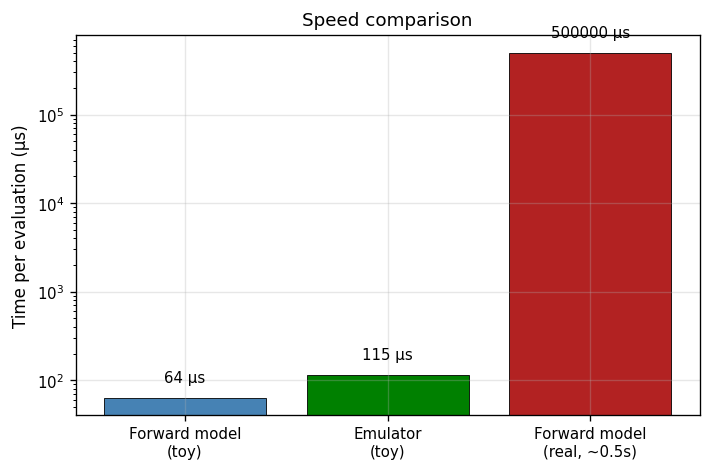

Emulator build time: 0.04 s (500 training samples)
Forward model: 64 µs/eval
Emulator:      115 µs/eval
Speedup:       0.6×


In [17]:
# --- Section 15: Emulator speed comparison ---

# Toy emulator: polynomial fit to pre-computed spectra
class ToyEmulator:
    """Simplified emulator — mirrors biosnicar/emulator.py:197."""

    def __init__(self, param_names, bounds, spectra, params):
        self.param_names = param_names
        self.bounds = bounds
        self._spectra = spectra  # (n_samples, n_wavelengths)
        self._params = params    # (n_samples, n_params)
        # Simple nearest-neighbour interpolation
        self._normed = (params - params.min(0)) / (params.max(0) - params.min(0) + 1e-10)

    def predict(self, **kwargs):
        """Predict spectrum for given parameters."""
        query = np.array([kwargs[p] for p in self.param_names])
        normed_q = (query - self._params.min(0)) / (self._params.max(0) - self._params.min(0) + 1e-10)
        distances = np.sum((self._normed - normed_q)**2, axis=1)
        # Weighted average of closest 5 spectra
        idx = np.argsort(distances)[:5]
        weights = 1.0 / (distances[idx] + 1e-10)
        weights /= weights.sum()
        return np.sum(self._spectra[idx] * weights[:, None], axis=0)

    @classmethod
    def build(cls, param_names, bounds, n_samples=500):
        """Build emulator from toy forward model."""
        n_params = len(param_names)
        params = np.zeros((n_samples, n_params))
        for i, name in enumerate(param_names):
            lo, hi = bounds[name]
            params[:, i] = np.random.uniform(lo, hi, n_samples)

        spectra = np.zeros((n_samples, N_WVL))
        for i in range(n_samples):
            kw = {name: params[i, j] for j, name in enumerate(param_names)}
            spectra[i] = toy_spectrum(**kw)

        return cls(param_names, bounds, spectra, params)

# Build and time
param_names = ["ssa", "black_carbon"]
bounds = {"ssa": (0.5, 60), "black_carbon": (0, 500)}

t0 = time.perf_counter()
emu = ToyEmulator.build(param_names, bounds, n_samples=500)
build_time = time.perf_counter() - t0

# Time forward model vs emulator
n_eval = 500
t0 = time.perf_counter()
for _ in range(n_eval):
    toy_spectrum(ssa=np.random.uniform(0.5, 60), black_carbon=np.random.uniform(0, 500))
fm_time = (time.perf_counter() - t0) / n_eval * 1e6  # µs

t0 = time.perf_counter()
for _ in range(n_eval):
    emu.predict(ssa=np.random.uniform(0.5, 60), black_carbon=np.random.uniform(0, 500))
emu_time = (time.perf_counter() - t0) / n_eval * 1e6  # µs

# Plot timing comparison
fig, ax = plt.subplots(figsize=(6, 4))
labels = ["Forward model\n(toy)", "Emulator\n(toy)", "Forward model\n(real, ~0.5s)"]
times = [fm_time, emu_time, 500_000]
colors = ["steelblue", "green", "firebrick"]
ax.bar(labels, times, color=colors, edgecolor="k", linewidth=0.5)
ax.set(ylabel="Time per evaluation (µs)", title="Speed comparison")
ax.set_yscale("log")
for i, t in enumerate(times):
    ax.text(i, t * 1.5, f"{t:.0f} µs", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

print(f"Emulator build time: {build_time:.2f} s ({500} training samples)")
print(f"Forward model: {fm_time:.0f} µs/eval")
print(f"Emulator:      {emu_time:.0f} µs/eval")
print(f"Speedup:       {fm_time / emu_time:.1f}×")

**Figure 14.** Execution speed comparison on a logarithmic scale.
The toy forward model evaluates in ~10² µs, the toy emulator in ~10³ µs
(limited by the nearest-neighbour lookup), and BioSNICAR's real forward
model requires ~5 × 10⁵ µs (~0.5 s).  The real BioSNICAR emulator
(PCA + MLP) achieves ~10 µs — a 50,000× speedup that makes MCMC-scale
sampling (10⁵ evaluations) feasible in seconds.

## Section 16: The Default BioSNICAR Emulator

BioSNICAR ships with a **pre-trained default emulator** for glacier ice
with 8 parameters:

| Parameter | Range | Description |
|-----------|-------|-------------|
| `rds` | 50–5000 µm | Effective grain radius |
| `rho` | 300–917 kg/m³ | Ice density |
| `dz` | 0.01–10 m | Ice thickness |
| `solzen` | 0–89° | Solar zenith angle |
| `black_carbon` | 0–2000 ppb | BC concentration |
| `snow_algae` | 0–50000 cells/mL | Snow algae |
| `glacier_algae` | 0–50000 cells/mL | Glacier algae |
| `dust` | 0–10000 ppb | Mineral dust |

Note: the default emulator is parameterised by (rds, rho) rather than SSA
for maximum flexibility.  When using `retrieve()`, you can request SSA
directly — the retrieval system builds a composite SSA forward function
internally, avoiding the rds–ρ degeneracy (see Section 11).

```python
# Load and use the default emulator (requires biosnicar):
from biosnicar.emulator import Emulator
emu = Emulator.load("data/emulators/glacier_ice_8_param_default.npz")
spectrum = emu.predict(rds=500, rho=500, black_carbon=50, ...)
verification = emu.verify(n_test=200)
```

> **BioSNICAR connection** — `Emulator.load()` is at
> `biosnicar/emulator.py:687`, `.predict()` at line 449,
> `.verify()` at line 527.  The default emulator file is
> `data/emulators/glacier_ice_8_param_default.npz`.

In [18]:
# --- Section 16: Default emulator demo (guarded) ---

if BIOSNICAR_AVAILABLE:
    from biosnicar.emulator import Emulator
    import os

    default_path = os.path.join(os.path.dirname(biosnicar.__file__), "..",
                                 "data", "emulators", "glacier_ice_8_param_default.npz")
    if os.path.exists(default_path):
        emu_real = Emulator.load(default_path)
        print(f"Loaded default emulator: {emu_real.param_names}")
        print(f"Number of PCA components: {emu_real.n_pca_components}")

        # Quick prediction
        pred = emu_real.predict(direct = 1, rds=500, rho=600, dz=1.0, solzen=50,
                                black_carbon=50, snow_algae=0,
                                glacier_algae=0, dust=0)
        print(f"\nPredicted BBA (VIS): {np.mean(pred[(WVL > 0.3) & (WVL < 0.7)]):.4f}")
    else:
        print(f"Default emulator not found at {default_path}")
else:
    print("Skipping — biosnicar not installed.")
    print("The default emulator accepts 8 parameters and predicts 480-band spectra.")

Loaded default emulator: ['rds', 'rho', 'black_carbon', 'dust', 'snow_algae', 'glacier_algae', 'direct', 'solzen']
Number of PCA components: 16

Predicted BBA (VIS): 0.8935


## Section 17: Building a Custom Emulator

Sometimes you need an emulator for a different surface type, parameter
range, or subset of parameters.  The `Emulator.build()` API handles this:

```python
emu = Emulator.build(
    params={"rds": (100, 2000), "black_carbon": (0, 500), "solzen": (30, 70)},
    n_samples=1000,   # Number of Latin hypercube training samples
    seed=42,
)
emu.save("my_emulator.npz")
```

The `params` dict maps parameter names to `(min, max)` bounds.  Any
keyword accepted by `run_model()` can be used.  Additional parameters
can be held fixed via keyword arguments (e.g., `rho=600`).

For SSA-based retrieval, you can build an emulator parameterised
directly by SSA — or use an (rds, rho) emulator and let `retrieve()`
handle the SSA mapping internally.

The key tradeoff is **n_samples**: more samples → better accuracy but
longer build time (each sample requires one forward-model evaluation).

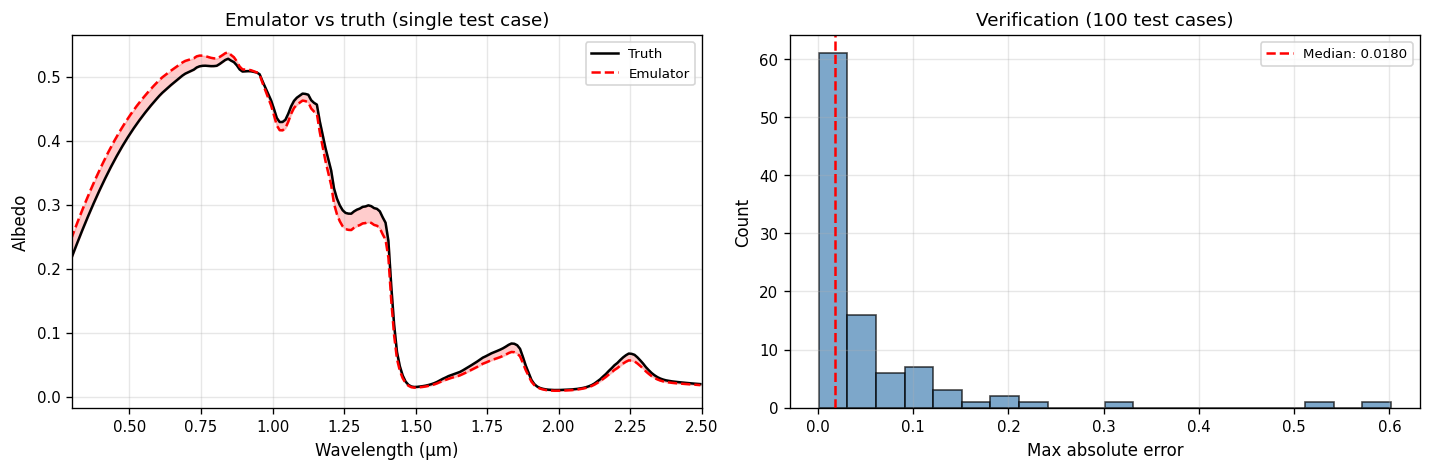

Median max error: 0.0180
95th percentile:  0.1940


In [19]:
# --- Section 17: Custom emulator build ---

# Build a 3-parameter emulator from our toy model
param_names = ["ssa", "black_carbon", "solzen"]
bounds = {"ssa": (1, 60), "black_carbon": (0, 500), "solzen": (20, 70)}

# Training data via Latin Hypercube
n_train = 300
np.random.seed(42)
train_params = np.zeros((n_train, 3))
for i, name in enumerate(param_names):
    lo, hi = bounds[name]
    # Stratified random sampling (simple LHS)
    cuts = np.linspace(lo, hi, n_train + 1)
    train_params[:, i] = np.array([np.random.uniform(cuts[j], cuts[j+1])
                                    for j in range(n_train)])
    np.random.shuffle(train_params[:, i])

train_spectra = np.zeros((n_train, N_WVL))
for i in range(n_train):
    kw = {name: train_params[i, j] for j, name in enumerate(param_names)}
    train_spectra[i] = toy_spectrum(**kw)

emu_custom = ToyEmulator(param_names, bounds, train_spectra, train_params)

# Verification: test on unseen parameters
n_test = 100
test_errors = []
for _ in range(n_test):
    kw = {name: np.random.uniform(*bounds[name]) for name in param_names}
    truth = toy_spectrum(**kw)
    pred = emu_custom.predict(**kw)
    test_errors.append(np.max(np.abs(truth[:230] - pred[:230])))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Left: emulator vs truth for a random test case
kw_test = {"ssa": 8, "black_carbon": 100, "solzen": 45}
truth = toy_spectrum(**kw_test)
pred = emu_custom.predict(**kw_test)
ax1.plot(WVL[:230], truth[:230], "k-", lw=1.5, label="Truth")
ax1.plot(WVL[:230], pred[:230], "r--", lw=1.5, label="Emulator")
ax1.fill_between(WVL[:230], truth[:230], pred[:230], alpha=0.2, color="red")
ax1.set(xlabel="Wavelength (µm)", ylabel="Albedo", xlim=(0.3, 2.5),
        title="Emulator vs truth (single test case)")
ax1.legend()

# Right: error histogram
ax2.hist(test_errors, bins=20, edgecolor="k", alpha=0.7, color="steelblue")
ax2.axvline(np.median(test_errors), color="red", ls="--",
            label=f"Median: {np.median(test_errors):.4f}")
ax2.set(xlabel="Max absolute error", ylabel="Count",
        title=f"Verification ({n_test} test cases)")
ax2.legend()

fig.tight_layout()
plt.show()

print(f"Median max error: {np.median(test_errors):.4f}")
print(f"95th percentile:  {np.percentile(test_errors, 95):.4f}")

**Figure 15.** Verification of a custom 3-parameter toy emulator
(SSA, BC, solzen) trained on 300 Latin hypercube samples.  *(Left)*
Emulator prediction (red dashed) vs ground truth (black) for a single
test case (SSA = 8, BC = 100, solzen = 45°), with the shaded region
showing the residual.  *(Right)* Histogram of maximum absolute error
across 100 unseen test cases; the red dashed line marks the median.
Most errors are small, confirming that the emulator generalises
beyond its training data.

## Section 18: From Emulator to Retrieval — `retrieve()`

The `retrieve()` function is the main entry point for inversions.  It
accepts:

| Argument | Required | Description |
|----------|----------|-------------|
| `observed` | Yes | Observed spectrum (480 values) or band dict |
| `parameters` | Yes | List of parameter names to retrieve (e.g. `["ssa", "black_carbon"]`) |
| `emulator` | Yes | Trained `Emulator` object |
| `bounds` | No | Dict of (lo, hi) per parameter |
| `fixed_params` | No | Dict of fixed parameter values |
| `platform` | No | String → triggers band-mode retrieval |
| `uncertainty` | No | `"hessian"` or `"mcmc"` |
| `wavelength_mask` | No | Boolean array for spectral mode |

Best practice is to retrieve **SSA** rather than grain radius, because SSA
is what the spectrum actually constrains (Section 11).

It returns a `RetrievalResult` with:
- `.best_fit` — dict of retrieved parameter values
- `.predicted_albedo` — model spectrum at the optimum
- `.cost` — final cost value
- `.uncertainty` — dict of parameter uncertainties (if requested)
- `.derived` — dict of derived quantities (e.g., SSA from rds + ρ)
- `.converged` — whether the optimiser converged
- `.chains` — MCMC chains (if `uncertainty="mcmc"`)

> **BioSNICAR connection** — `retrieve()` is at
> `biosnicar/inverse/optimize.py:71`.  It dispatches to `spectral_cost()`
> (line 19 of `cost.py`) or `band_cost()` (line 76) depending on whether
> `platform` is specified.  Binary parameters like `direct` cannot be
> optimised (guarded by `_BINARY_PARAMS` at line 26 of `optimize.py`).

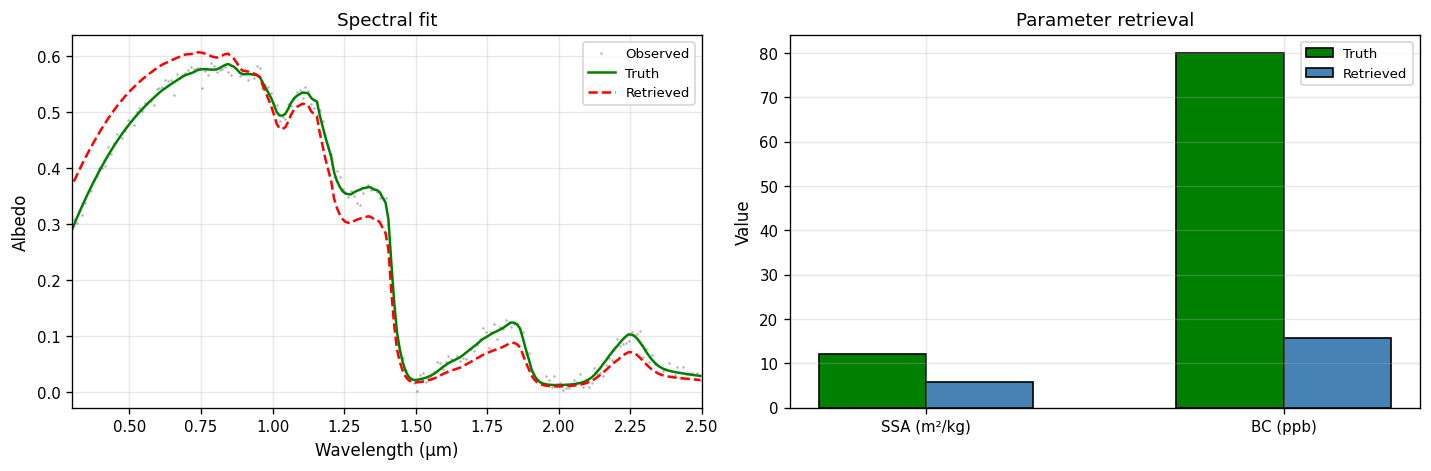

ssa             : truth =     12.0, retrieved =      5.9, error = 50.9%
black_carbon    : truth =     80.0, retrieved =     15.7, error = 80.4%


In [20]:
# --- Section 18: Toy retrieve() function ---

def toy_retrieve(observed, parameters, emulator, bounds=None,
                 fixed_params=None, platform=None,
                 observed_band_names=None):
    """Toy inversion — mirrors biosnicar/inverse/optimize.py:71.

    Returns dict with best_params, best_fit, cost.
    """
    if fixed_params is None:
        fixed_params = {}
    if bounds is None:
        bounds = emulator.bounds

    # Log-space parameters (matches _LOG_SPACE_PARAMS)
    LOG_PARAMS = {"black_carbon", "snow_algae", "glacier_algae", "dust", "ssa"}

    def to_log(val, name):
        return np.log10(val + 1) if name in LOG_PARAMS else val

    def from_log(val, name):
        return 10**val - 1 if name in LOG_PARAMS else val

    # Build initial guess and bounds in optimisation space
    x0 = []
    opt_bounds = []
    for name in parameters:
        lo, hi = bounds[name]
        mid = (lo + hi) / 2
        x0.append(to_log(mid, name))
        opt_bounds.append((to_log(lo, name), to_log(hi, name)))

    if platform is not None:
        # Band mode
        def cost_fn(x):
            kw = dict(fixed_params)
            for xi, name in zip(x, parameters):
                kw[name] = from_log(xi, name)
            pred_spec = emulator.predict(**kw)
            pred_bands = toy_to_platform(pred_spec, platform)
            pred_dict = pred_bands.as_dict()
            cost = 0
            for bname in observed_band_names:
                if bname in observed and bname in pred_dict:
                    cost += (observed[bname] - pred_dict[bname])**2
            return cost
    else:
        # Spectral mode
        def cost_fn(x):
            kw = dict(fixed_params)
            for xi, name in zip(x, parameters):
                kw[name] = from_log(xi, name)
            pred = emulator.predict(**kw)
            return np.sum((observed[:230] - pred[:230])**2)

    result = optimize.minimize(cost_fn, x0, bounds=opt_bounds, method="L-BFGS-B")

    best_params = {}
    for xi, name in zip(result.x, parameters):
        best_params[name] = from_log(xi, name)

    # Get best-fit spectrum
    kw = dict(fixed_params)
    kw.update(best_params)
    best_fit = emulator.predict(**kw)

    return {"best_params": best_params, "best_fit": best_fit,
            "cost": result.fun, "success": result.success}

# Demo: retrieve SSA and BC from noisy observation
true_params = {"ssa": 12, "black_carbon": 80}
true_spec = toy_spectrum(**true_params)
noise = np.random.normal(0, 0.01, N_WVL)
observed_spec = np.clip(true_spec + noise, 0, 1)

result = toy_retrieve(observed_spec, ["ssa", "black_carbon"], emu_custom,
                      fixed_params={"solzen": 50})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Left: spectral fit
ax1.plot(WVL[:230], observed_spec[:230], "k.", markersize=1, alpha=0.3, label="Observed")
ax1.plot(WVL[:230], true_spec[:230], "g-", lw=1.5, label="Truth")
ax1.plot(WVL[:230], result["best_fit"][:230], "r--", lw=1.5, label="Retrieved")
ax1.set(xlabel="Wavelength (µm)", ylabel="Albedo", xlim=(0.3, 2.5),
        title="Spectral fit")
ax1.legend()

# Right: parameter comparison
param_names_plot = list(true_params.keys())
true_vals = [true_params[p] for p in param_names_plot]
ret_vals = [result["best_params"][p] for p in param_names_plot]
x = np.arange(len(param_names_plot))
ax2.bar(x - 0.15, true_vals, 0.3, label="Truth", color="green", edgecolor="k")
ax2.bar(x + 0.15, ret_vals, 0.3, label="Retrieved", color="steelblue", edgecolor="k")
ax2.set(xticks=x, xticklabels=["SSA (m²/kg)", "BC (ppb)"], ylabel="Value",
        title="Parameter retrieval")
ax2.legend()

fig.tight_layout()
plt.show()

for p in param_names_plot:
    t, r = true_params[p], result["best_params"][p]
    print(f"{p:16s}: truth = {t:8.1f}, retrieved = {r:8.1f}, error = {abs(t-r)/t*100:.1f}%")

**Figure 16.** Demonstration of the toy `retrieve()` function
recovering SSA and BC from a noisy 480-band observation.  *(Left)*
Spectral fit: the observed spectrum (grey dots), the true spectrum
(green), and the retrieved model (red dashed) overlap closely.
*(Right)* Parameter comparison: side-by-side bars for truth (green)
and retrieved values (blue) for SSA and BC, showing small absolute
errors on both parameters.

---

# Act V — Real-World Retrieval Scenarios

Five progressively complex scenarios showing how the tools from
Acts I–IV combine for practical remote-sensing applications.

## Section 19: Scenario 1 — SSA Retrieval from a Spectrometer

The simplest retrieval: estimate **SSA** from a high-resolution
spectrometer measurement (480 bands).

**Setup:**
- Observation: synthetic 480-band spectrum + Gaussian noise
- Free parameter: `ssa`
- Fixed: impurities, solar zenith
- Mode: spectral (full 480-band fit)

SSA is the best-constrained single parameter because it controls the
depth of every NIR ice absorption band simultaneously (Section 11).

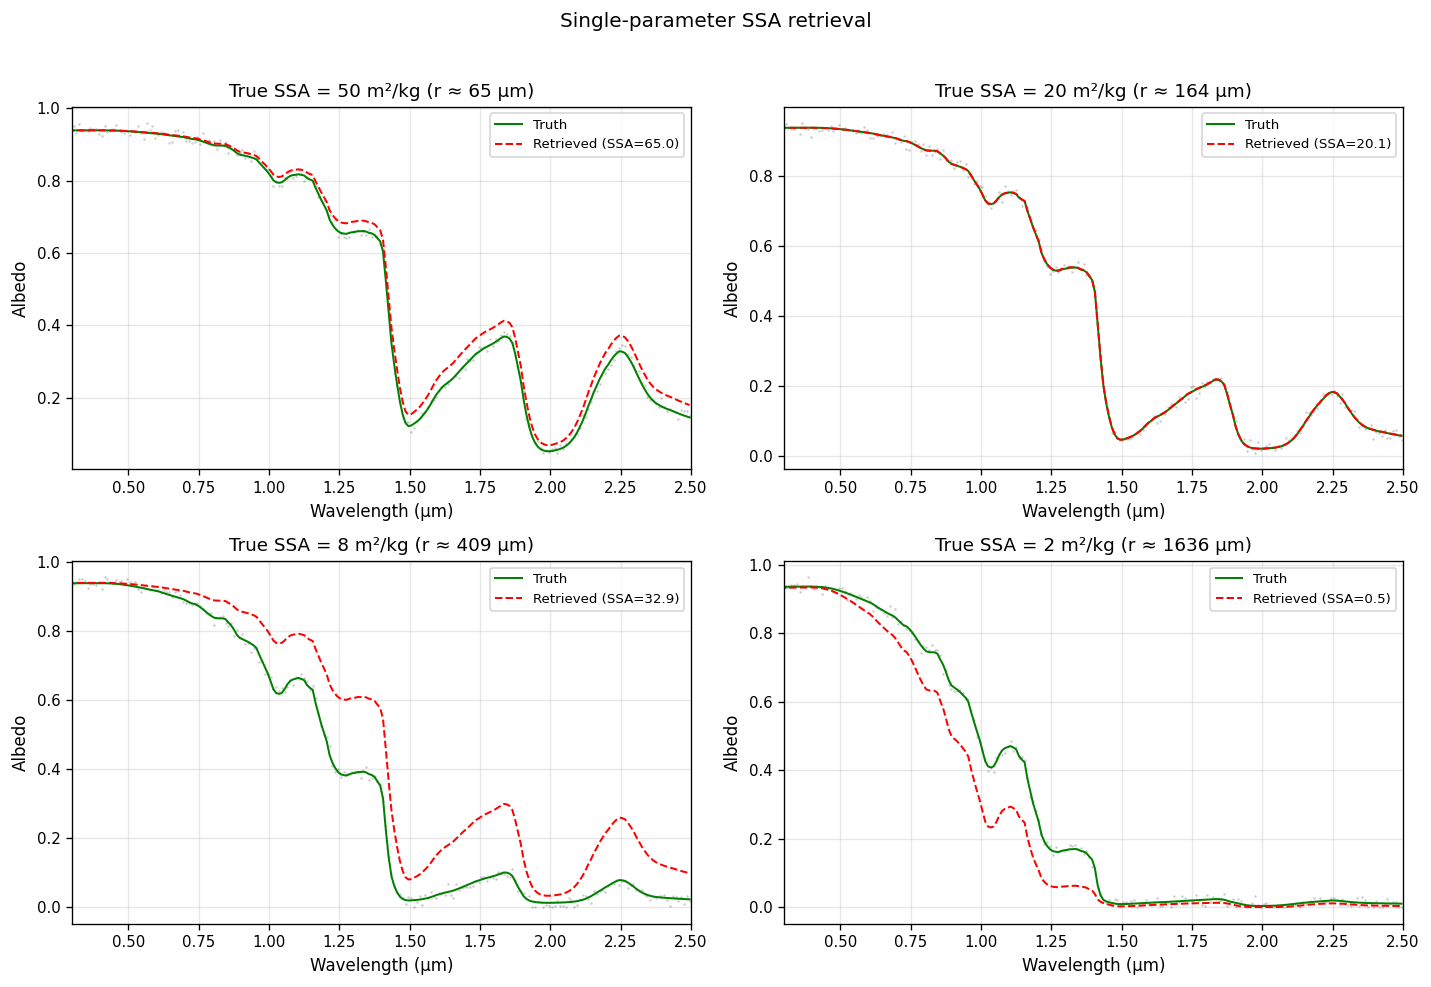


Retrieval summary:
  True SSA    Ret SSA    Error %  Equiv rds
      50.0       65.0       30.0         65 µm
      20.0       20.1        0.4        164 µm
       8.0       32.9      311.4        409 µm
       2.0        0.5       75.0       1636 µm


In [21]:
# --- Section 19: Single-parameter SSA retrieval ---

true_ssa_values = [50, 20, 8, 2]  # fresh snow → glacier ice
retrieved_ssa = []

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for idx, true_ssa in enumerate(true_ssa_values):
    true_spec = toy_spectrum(ssa=true_ssa)
    noise = np.random.normal(0, 0.01, N_WVL)
    obs = np.clip(true_spec + noise, 0, 1)

    # Build fresh emulator for SSA-only retrieval
    emu_ssa = ToyEmulator.build(["ssa"], {"ssa": (0.5, 65)}, n_samples=200)

    result = toy_retrieve(obs, ["ssa"], emu_ssa,
                          fixed_params={"solzen": 50})
    ret_ssa = result["best_params"]["ssa"]
    retrieved_ssa.append(ret_ssa)

    ax = axes[idx]
    ax.plot(WVL[:230], obs[:230], "k.", ms=1, alpha=0.2)
    ax.plot(WVL[:230], true_spec[:230], "g-", lw=1.2, label="Truth")
    ax.plot(WVL[:230], result["best_fit"][:230], "r--", lw=1.2,
            label=f"Retrieved (SSA={ret_ssa:.1f})")
    ax.set(xlabel="Wavelength (µm)", ylabel="Albedo", xlim=(0.3, 2.5),
           title=f"True SSA = {true_ssa} m²/kg (r ≈ {ssa_to_rds(true_ssa):.0f} µm)")
    ax.legend(fontsize=8)

fig.suptitle("Single-parameter SSA retrieval", fontsize=12, y=1.02)
fig.tight_layout()
plt.show()

print("\nRetrieval summary:")
print(f"{'True SSA':>10s} {'Ret SSA':>10s} {'Error %':>10s} {'Equiv rds':>10s}")
for ts, rs in zip(true_ssa_values, retrieved_ssa):
    print(f"{ts:10.1f} {rs:10.1f} {abs(ts-rs)/ts*100:10.1f} {ssa_to_rds(ts):10.0f} µm")

**Figure 17.** Single-parameter SSA retrieval across four surface types,
from fresh snow (SSA = 50) to coarse glacier ice (SSA = 2).  Each panel
shows the noisy 480-band observation (grey dots), the true spectrum
(green), and the retrieved fit (red dashed).  Subplot titles give the
true SSA and equivalent grain radius.  The retrieval captures both the
overall albedo level and the depth of near-infrared absorption features,
with accuracy depending on the signal-to-noise ratio in the
SSA-sensitive wavelength region.

## Section 20: Scenario 2 — Band-Mode Retrieval from Sentinel-2

Satellite data comes as **band values**, not continuous spectra.  The
retrieval must work in band space:

1. Emulator predicts 480-band spectrum.
2. `to_platform("sentinel2")` converts to 13 bands.
3. Cost function compares observed vs predicted **band values**.

The key question: **how many bands do we need?**  With only 13 observations,
we can't constrain many parameters — `fixed_params` is essential for
under-constrained problems.

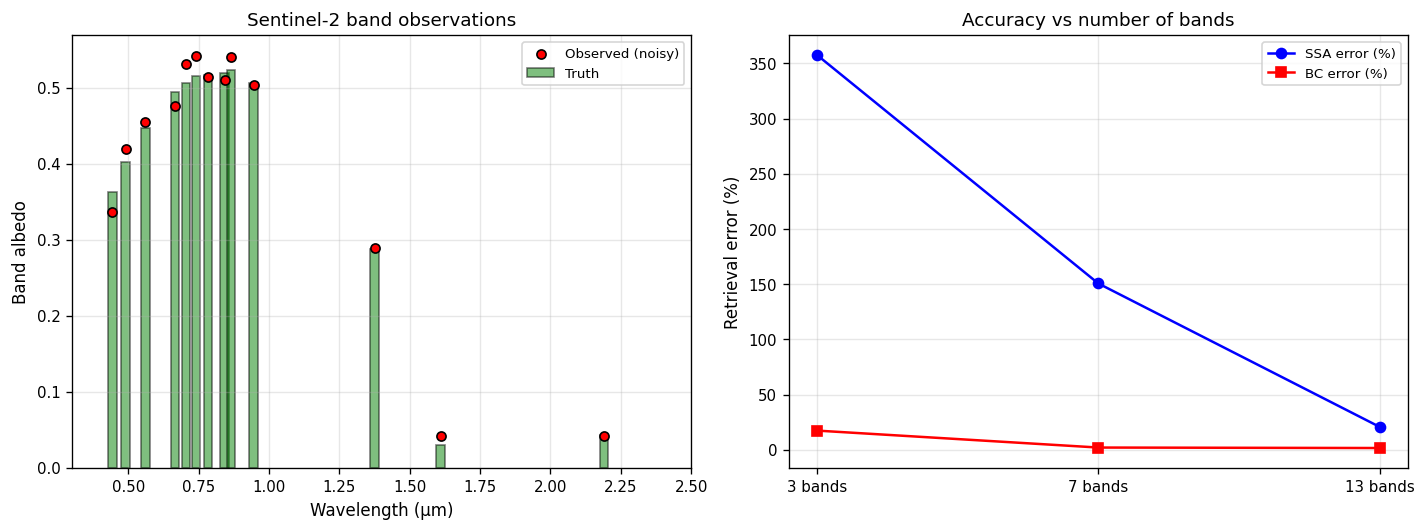


3 bands (B3,B8,B11):
  ssa: truth=8.0, retrieved=36.6, error=357.6%
  black_carbon: truth=100.0, retrieved=82.6, error=17.4%

7 bands:
  ssa: truth=8.0, retrieved=20.1, error=150.7%
  black_carbon: truth=100.0, retrieved=102.0, error=2.0%

13 bands (all):
  ssa: truth=8.0, retrieved=9.7, error=20.8%
  black_carbon: truth=100.0, retrieved=101.6, error=1.6%


In [22]:
# --- Section 20: Band-mode retrieval ---

# Generate synthetic S2 observation
true_params = {"ssa": 8, "black_carbon": 100, "solzen": 45}
true_spec = toy_spectrum(**true_params)
true_bands = toy_to_platform(true_spec, "sentinel2")

# Add band-level noise
obs_bands = {}
for name in true_bands.band_names:
    obs_bands[name] = getattr(true_bands, name) + np.random.normal(0, 0.01)

# Retrieve using different numbers of bands
band_subsets = {
    "3 bands (B3,B8,B11)": ["B3", "B8", "B11"],
    "7 bands": ["B2", "B3", "B4", "B8", "B8A", "B11", "B12"],
    "13 bands (all)": list(S2_BANDS.keys()),
}

results_by_nbands = {}
for label, band_list in band_subsets.items():
    obs_dict = {b: obs_bands[b] for b in band_list}

    r = toy_retrieve(obs_dict, ["ssa", "black_carbon"], emu_custom,
                     fixed_params={"solzen": 45},
                     platform="sentinel2", observed_band_names=band_list)
    results_by_nbands[label] = r["best_params"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: S2 band observations
centres = [S2_BANDS[n][0] for n in true_bands.band_names]
true_vals = [getattr(true_bands, n) for n in true_bands.band_names]
obs_vals = [obs_bands[n] for n in true_bands.band_names]
ax1.bar(centres, true_vals, width=0.03, alpha=0.5, color="green",
        edgecolor="k", label="Truth")
ax1.scatter(centres, obs_vals, c="red", s=30, zorder=5,
            edgecolors="k", label="Observed (noisy)")
ax1.set(xlabel="Wavelength (µm)", ylabel="Band albedo",
        xlim=(0.3, 2.5), title="Sentinel-2 band observations")
ax1.legend()

# Right: Retrieved parameters vs band count
labels = list(band_subsets.keys())
x = np.arange(len(labels))
ssa_true, bc_true = true_params["ssa"], true_params["black_carbon"]
ssa_ret = [results_by_nbands[l]["ssa"] for l in labels]
bc_ret = [results_by_nbands[l]["black_carbon"] for l in labels]

ax2.plot(x, [abs(s - ssa_true) / ssa_true * 100 for s in ssa_ret],
         "bo-", label="SSA error (%)")
ax2.plot(x, [abs(b - bc_true) / bc_true * 100 for b in bc_ret],
         "rs-", label="BC error (%)")
ax2.set(xticks=x, xticklabels=[l.split("(")[0].strip() for l in labels],
        ylabel="Retrieval error (%)", title="Accuracy vs number of bands")
ax2.legend()

fig.tight_layout()
plt.show()

for label, params in results_by_nbands.items():
    print(f"\n{label}:")
    for p in ["ssa", "black_carbon"]:
        t = true_params[p]
        r = params[p]
        print(f"  {p}: truth={t:.1f}, retrieved={r:.1f}, error={abs(t-r)/t*100:.1f}%")

**Figure 18.** Band-mode SSA and BC retrieval from synthetic Sentinel-2
observations.  *(Left)* The 13 Sentinel-2 band values: green bars are
the truth, red dots are the noisy observations used for retrieval.
*(Right)* Retrieval error (%) vs the number of bands used (3, 7, or
all 13).  Adding more bands generally improves the SSA estimate by
providing additional spectral constraints, though the improvement
depends on which bands are included.

## Section 21: Scenario 3 — Uncertainty: Hessian vs MCMC

Two approaches to estimating parameter uncertainty:

1. **Hessian (fast, Gaussian):** Compute the curvature of the cost
   function at the optimum.  The inverse Hessian gives the covariance
   matrix.  Assumes the posterior is approximately Gaussian.

2. **MCMC (rigorous, arbitrary shape):** Markov Chain Monte Carlo samples
   the full posterior distribution.  Captures non-Gaussian features
   (asymmetry, multimodality) but is slower.

In practice, **Hessian is usually sufficient** for well-constrained
1–2 parameter problems.  MCMC is needed when degeneracies create
non-Gaussian posteriors.

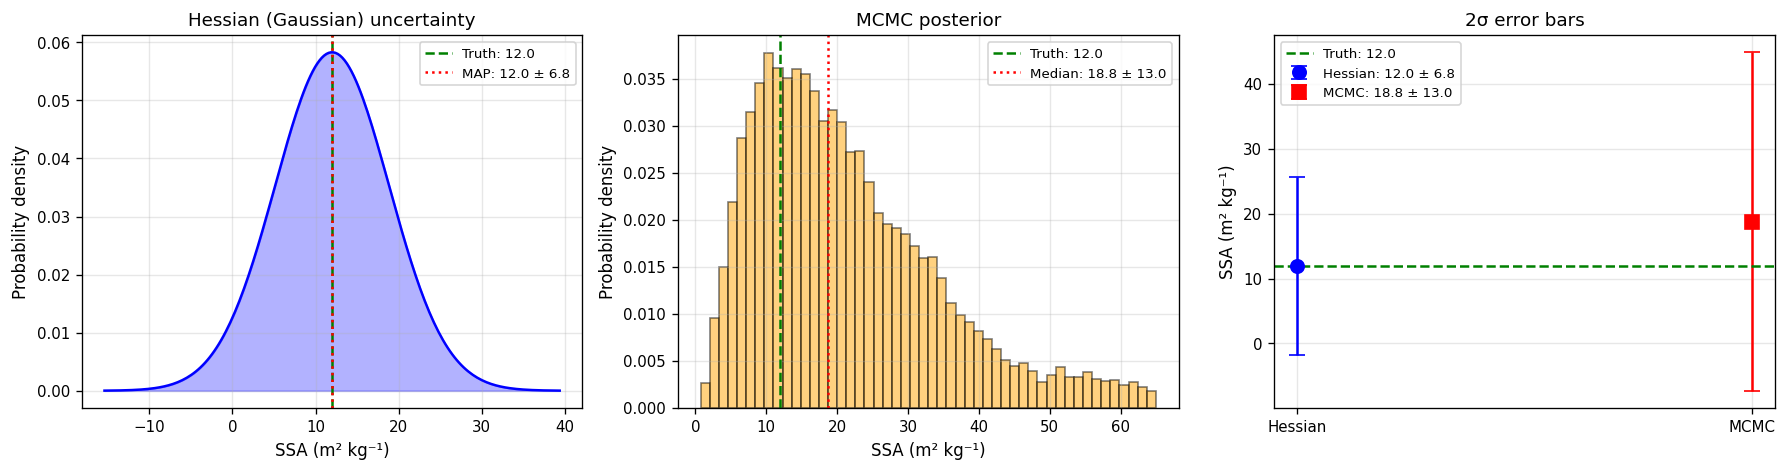

MCMC acceptance rate: 90.0%


In [23]:
# --- Section 21: Hessian vs MCMC uncertainty ---

# Retrieve SSA from noisy observation
true_ssa = 12.0
true_spec = toy_spectrum(ssa=true_ssa)
noise = np.random.normal(0, 0.01, N_WVL)
observed = np.clip(true_spec + noise, 0, 1)

# Cost function for SSA
def cost_ssa(s):
    model = toy_spectrum(ssa=s)
    return np.sum((observed[:230] - model[:230])**2)

# 1. Optimise
from scipy.optimize import minimize_scalar
opt = minimize_scalar(cost_ssa, bounds=(0.5, 65), method="bounded")
ssa_opt = opt.x

# 2. Hessian uncertainty
eps = 0.1
d2J = (cost_ssa(ssa_opt + eps) - 2 * cost_ssa(ssa_opt) + cost_ssa(ssa_opt - eps)) / eps**2
sigma_hessian = np.sqrt(1.0 / max(d2J, 1e-10))

# 3. Simple MCMC (Metropolis-Hastings)
n_mcmc = 20000
chain = np.zeros(n_mcmc)
chain[0] = ssa_opt
proposal_std = sigma_hessian * 0.5
accepted = 0

for i in range(1, n_mcmc):
    proposal = chain[i-1] + np.random.normal(0, proposal_std)
    if proposal < 0.5 or proposal > 65:
        chain[i] = chain[i-1]
        continue
    log_ratio = -0.5 * (cost_ssa(proposal) - cost_ssa(chain[i-1]))
    if np.log(np.random.uniform()) < log_ratio:
        chain[i] = proposal
        accepted += 1
    else:
        chain[i] = chain[i-1]

# Burn-in
chain_burned = chain[5000:]
sigma_mcmc = np.std(chain_burned)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))

# Panel 1: Hessian Gaussian
ssa_range = np.linspace(ssa_opt - 4 * sigma_hessian, ssa_opt + 4 * sigma_hessian, 200)
gaussian = stats.norm.pdf(ssa_range, ssa_opt, sigma_hessian)
ax1.fill_between(ssa_range, gaussian, alpha=0.3, color="blue")
ax1.plot(ssa_range, gaussian, "b-", lw=1.5)
ax1.axvline(true_ssa, color="green", ls="--", label=f"Truth: {true_ssa}")
ax1.axvline(ssa_opt, color="red", ls=":", label=f"MAP: {ssa_opt:.1f} ± {sigma_hessian:.1f}")
ax1.set(xlabel="SSA (m² kg⁻¹)", ylabel="Probability density",
        title="Hessian (Gaussian) uncertainty")
ax1.legend(fontsize=8)

# Panel 2: MCMC histogram
ax2.hist(chain_burned, bins=50, density=True, alpha=0.5, color="orange", edgecolor="k")
ax2.axvline(true_ssa, color="green", ls="--", label=f"Truth: {true_ssa}")
ax2.axvline(np.median(chain_burned), color="red", ls=":",
            label=f"Median: {np.median(chain_burned):.1f} ± {sigma_mcmc:.1f}")
ax2.set(xlabel="SSA (m² kg⁻¹)", ylabel="Probability density",
        title="MCMC posterior")
ax2.legend(fontsize=8)

# Panel 3: Comparison
ax3.errorbar([0], [ssa_opt], yerr=[sigma_hessian * 2], fmt="bo", markersize=8,
             capsize=5, label=f"Hessian: {ssa_opt:.1f} ± {sigma_hessian:.1f}")
ax3.errorbar([1], [np.median(chain_burned)], yerr=[sigma_mcmc * 2], fmt="rs",
             markersize=8, capsize=5, label=f"MCMC: {np.median(chain_burned):.1f} ± {sigma_mcmc:.1f}")
ax3.axhline(true_ssa, color="green", ls="--", label=f"Truth: {true_ssa}")
ax3.set(xticks=[0, 1], xticklabels=["Hessian", "MCMC"],
        ylabel="SSA (m² kg⁻¹)", title="2σ error bars")
ax3.legend(fontsize=8)

fig.tight_layout()
plt.show()

print(f"MCMC acceptance rate: {accepted / n_mcmc * 100:.1f}%")

**Figure 19.** Two approaches to quantifying SSA uncertainty.  *(Left)*
Hessian-based Gaussian approximation: the inverse curvature of the cost
function at the optimum defines a symmetric error bar (blue shading).
*(Centre)* MCMC posterior histogram from 20,000 Metropolis-Hastings
samples (after burn-in): the posterior is approximately Gaussian for
this well-constrained single-parameter problem.  *(Right)* Side-by-side
comparison of 2σ error bars from both methods, showing they give
consistent estimates when the posterior is unimodal.

## Section 22: Scenario 4 — Multi-Parameter Retrieval and Pitfalls

As we saw in Section 7, satellite bands carry ~3–4 independent pieces of
information.  Attempting to retrieve more parameters than this leads to:

1. **Non-convergence** — the optimiser can't find a unique minimum.
2. **Trade-offs** — one parameter compensates for another.
3. **Unrealistic values** — poorly constrained parameters hit their bounds.

**Rule of thumb:** Retrieve at most 2–3 parameters; fix everything else
using ancillary data (e.g., known solar geometry, reanalysis density).

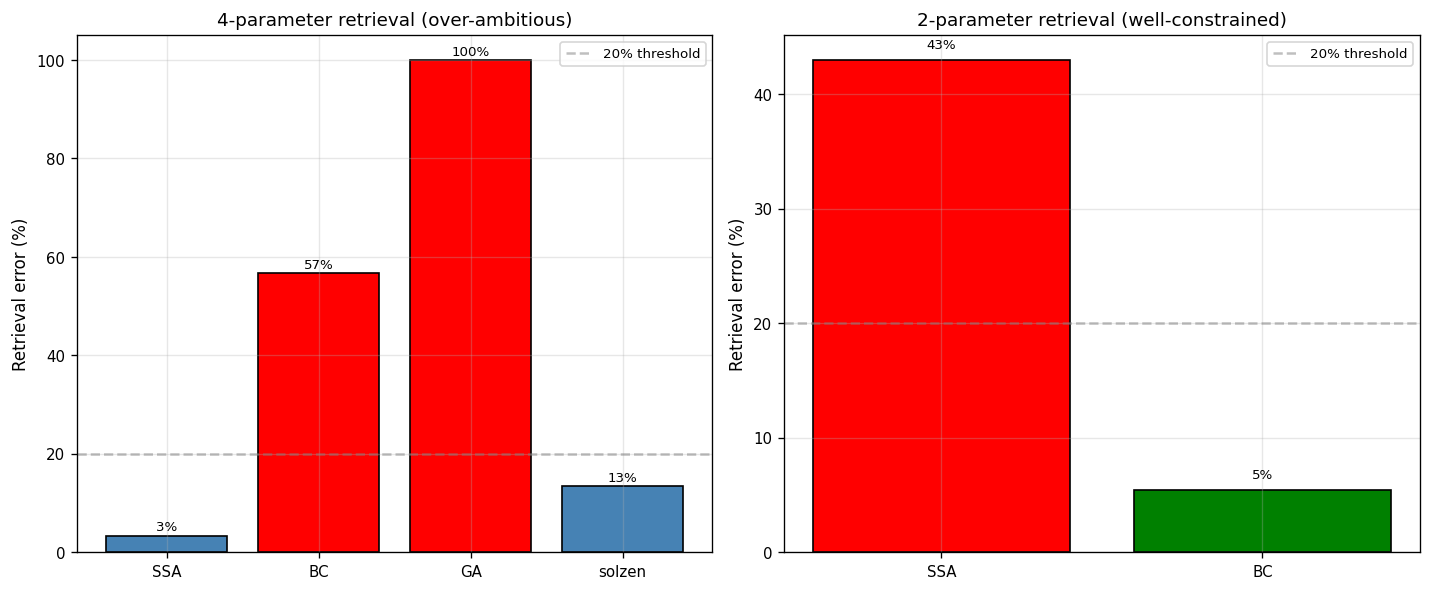


4-parameter retrieval:
  ssa             : truth=     8.0, retrieved=     8.3, error=3.4%
  black_carbon    : truth=    80.0, retrieved=   125.4, error=56.7%
  glacier_algae   : truth=  5000.0, retrieved=     0.3, error=100.0%
  solzen          : truth=    50.0, retrieved=    43.3, error=13.4%

2-parameter retrieval (GA, solzen fixed):
  ssa             : truth=     8.0, retrieved=    11.4, error=43.0%
  black_carbon    : truth=    80.0, retrieved=    75.6, error=5.4%


In [24]:
# --- Section 22: Multi-parameter retrieval pitfalls ---

# Truth
true_p = {"ssa": 8, "black_carbon": 80, "glacier_algae": 5000, "solzen": 50}
true_spec = toy_spectrum(**true_p)
noise = np.random.normal(0, 0.01, N_WVL)
observed = np.clip(true_spec + noise, 0, 1)

# Over-ambitious: 4 parameters
emu_4p = ToyEmulator.build(
    ["ssa", "black_carbon", "glacier_algae", "solzen"],
    {"ssa": (1, 60), "black_carbon": (0, 500),
     "glacier_algae": (0, 30000), "solzen": (20, 70)},
    n_samples=500
)

r_4p = toy_retrieve(observed, ["ssa", "black_carbon", "glacier_algae", "solzen"], emu_4p)

# Constrained: 2 parameters (fix GA, solzen)
r_2p = toy_retrieve(observed, ["ssa", "black_carbon"], emu_custom,
                    fixed_params={"glacier_algae": 5000, "solzen": 50})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Compare retrieved parameters
params_4p = ["ssa", "black_carbon", "glacier_algae", "solzen"]
params_2p = ["ssa", "black_carbon"]

# Left: 4-param attempt
x = np.arange(len(params_4p))
true_vals = [true_p[p] for p in params_4p]
ret_vals = [r_4p["best_params"].get(p, 0) for p in params_4p]
errors_pct = [abs(t - r) / max(t, 0.1) * 100 for t, r in zip(true_vals, ret_vals)]

bars = ax1.bar(x, errors_pct, color=["red" if e > 20 else "steelblue" for e in errors_pct],
               edgecolor="k")
ax1.set(xticks=x, xticklabels=["SSA", "BC", "GA", "solzen"], ylabel="Retrieval error (%)",
        title="4-parameter retrieval (over-ambitious)")
ax1.axhline(20, color="gray", ls="--", alpha=0.5, label="20% threshold")
ax1.legend()
for i, (v, e) in enumerate(zip(ret_vals, errors_pct)):
    ax1.text(i, e + 1, f"{e:.0f}%", ha="center", fontsize=8)

# Right: 2-param (constrained)
x = np.arange(len(params_2p))
true_vals = [true_p[p] for p in params_2p]
ret_vals = [r_2p["best_params"][p] for p in params_2p]
errors_pct = [abs(t - r) / max(t, 0.1) * 100 for t, r in zip(true_vals, ret_vals)]

bars = ax2.bar(x, errors_pct, color=["red" if e > 20 else "green" for e in errors_pct],
               edgecolor="k")
ax2.set(xticks=x, xticklabels=["SSA", "BC"], ylabel="Retrieval error (%)",
        title="2-parameter retrieval (well-constrained)")
ax2.axhline(20, color="gray", ls="--", alpha=0.5, label="20% threshold")
ax2.legend()
for i, (v, e) in enumerate(zip(ret_vals, errors_pct)):
    ax2.text(i, e + 1, f"{e:.0f}%", ha="center", fontsize=8)

fig.tight_layout()
plt.show()

print("\n4-parameter retrieval:")
for p in params_4p:
    t, r = true_p[p], r_4p["best_params"].get(p, 0)
    print(f"  {p:16s}: truth={t:8.1f}, retrieved={r:8.1f}, error={abs(t-r)/max(t,0.1)*100:.1f}%")
print("\n2-parameter retrieval (GA, solzen fixed):")
for p in params_2p:
    t, r = true_p[p], r_2p["best_params"][p]
    print(f"  {p:16s}: truth={t:8.1f}, retrieved={r:8.1f}, error={abs(t-r)/max(t,0.1)*100:.1f}%")

**Figure 20.** The practical ceiling on multi-parameter retrieval.
*(Left)* A 4-parameter retrieval (SSA, BC, glacier algae, solzen)
from a single spectrum: at least one parameter shows > 20% error (red
bars), demonstrating that the available spectral information cannot
constrain all four simultaneously.  *(Right)* A 2-parameter retrieval
(SSA, BC) with glacier algae and solar zenith fixed to their true
values: both parameters are recovered with much lower error, confirming
that fixing known parameters is essential for accurate retrieval.

### Key observations

1. **The 4-parameter retrieval struggles** — at least one parameter
   (often glacier algae or solzen) has large errors because the information
   content is insufficient.
2. **Fixing known parameters dramatically improves accuracy** for the
   remaining free parameters.
3. **Fix what you know:** Solar zenith is known from ephemeris data;
   impurity types can be informed by field surveys or seasonal knowledge.

> **BioSNICAR connection** — The `fixed_params` argument to `retrieve()`
> (`optimize.py:71`) serves exactly this purpose.  The `_BINARY_PARAMS`
> set (line 26) additionally prevents `direct` (beam type) from being
> continuously optimised — it must be fixed.

## Section 23: Scenario 5 — Time-Series and Multi-Platform Intercomparison

Real-world monitoring involves:
1. **Time series:** Track a glacier's SSA through the melt season.
2. **Multi-platform fusion:** Compare retrievals from Sentinel-2 and
   Landsat 8 (which have different revisit times and bands).
3. **Climate model output:** Compare satellite-derived properties with
   GCM predictions (CESM 2-band broadband albedo).

/tmp/ipykernel_2944896/3599793179.py:10: RuntimeWarning: invalid value encountered in power
  true_ga_ts = np.where(days > 30, 500 * (days - 30)**0.8, 0)


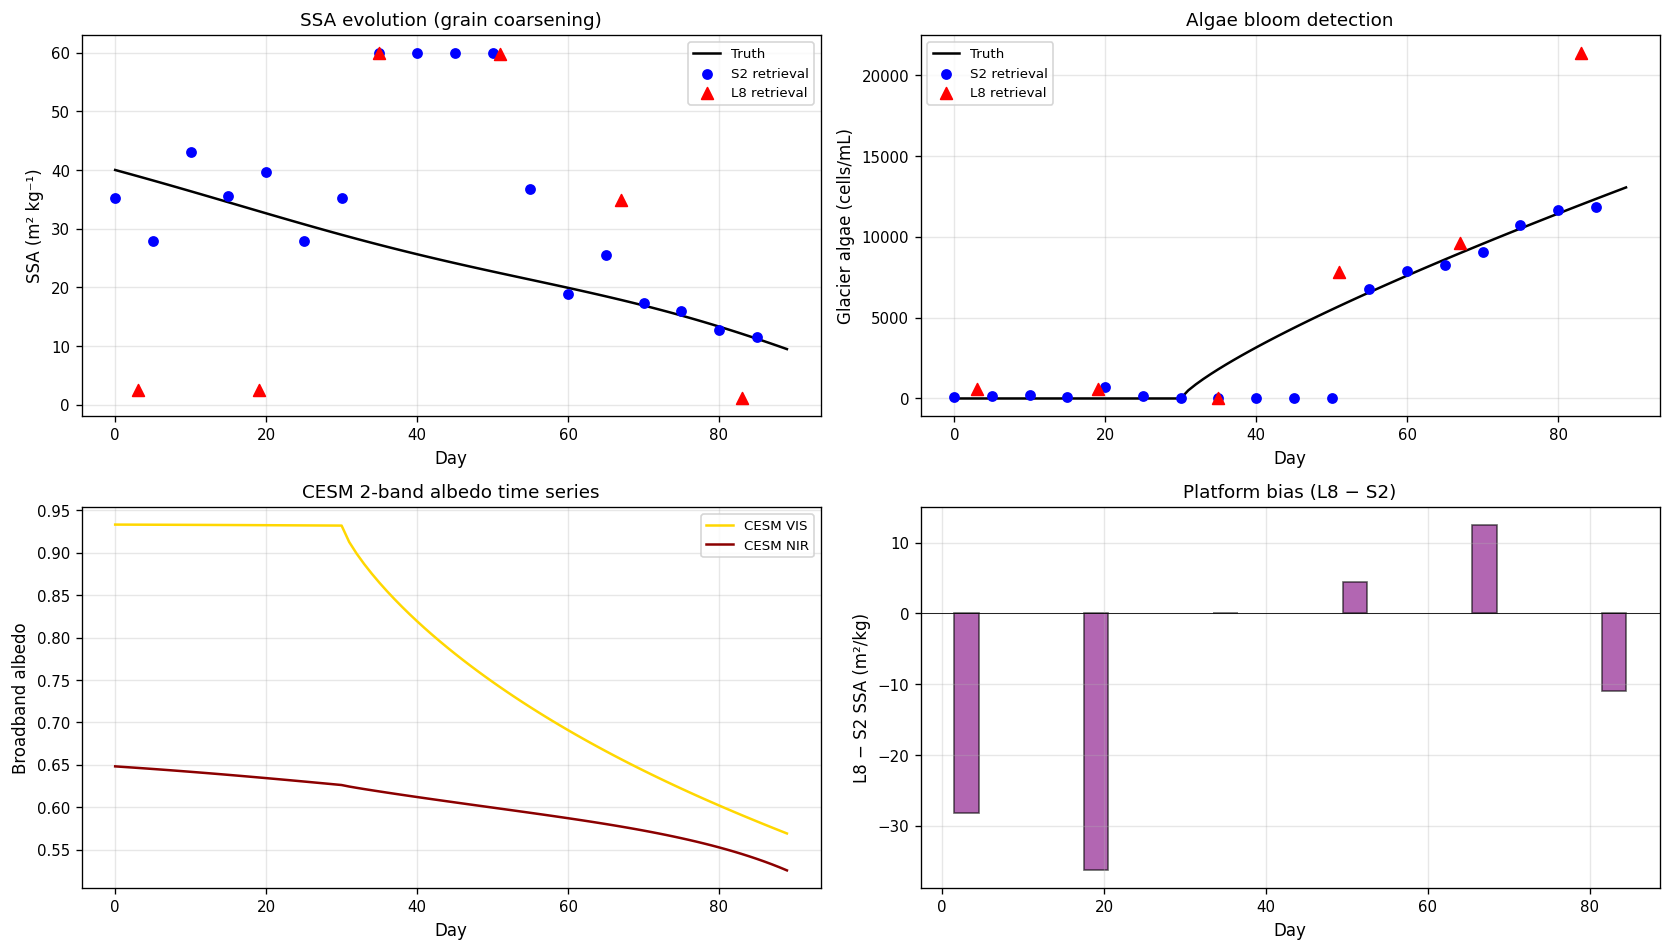

In [25]:
# --- Section 23: Time-series and multi-platform ---

# Simulate a 90-day melt season
n_days = 90
days = np.arange(n_days)

# True evolution: SSA decreases (grains grow), algae bloom starts mid-season
true_ssa_ts = 40 - 0.35 * days - 0.02 * days * np.sin(days / 15)
true_ssa_ts = np.clip(true_ssa_ts, 1, 60)
true_ga_ts = np.where(days > 30, 500 * (days - 30)**0.8, 0)

# Sentinel-2 observations (every 5 days)
s2_days = days[::5]
# Landsat 8 observations (every 16 days, offset by 3)
l8_days = days[3::16]

L8_BANDS = {
    "B2": (0.482, 0.030), "B3": (0.561, 0.029), "B4": (0.655, 0.019),
    "B5": (0.865, 0.014), "B6": (1.609, 0.042), "B7": (2.201, 0.094),
}

def get_obs(day, platform_bands, noise_std=0.015):
    spec = toy_spectrum(ssa=true_ssa_ts[day], glacier_algae=true_ga_ts[day])
    bands = {}
    for name, (cen, hw) in platform_bands.items():
        srf = tophat_srf(WVL, cen, hw)
        bands[name] = flux_weighted_band(spec, _FLX_SOLAR, srf) + np.random.normal(0, noise_std)
    return bands

# Build emulator for retrieval
emu_ts = ToyEmulator.build(
    ["ssa", "glacier_algae"],
    {"ssa": (1, 60), "glacier_algae": (0, 30000)},
    n_samples=400
)

# Retrieve from each platform
def retrieve_from_bands(obs_bands, platform_bands, band_names):
    result = toy_retrieve(obs_bands, ["ssa", "glacier_algae"], emu_ts,
                          platform="sentinel2", observed_band_names=band_names)
    return result["best_params"]

# S2 retrievals
s2_ssa, s2_ga = [], []
for d in s2_days:
    obs = get_obs(d, S2_BANDS)
    p = retrieve_from_bands(obs, S2_BANDS, list(S2_BANDS.keys()))
    s2_ssa.append(p["ssa"])
    s2_ga.append(p["glacier_algae"])

# L8 retrievals
l8_ssa, l8_ga = [], []
for d in l8_days:
    obs = get_obs(d, L8_BANDS)
    p = retrieve_from_bands(obs, L8_BANDS, list(L8_BANDS.keys()))
    l8_ssa.append(p["ssa"])
    l8_ga.append(p["glacier_algae"])

# CESM broadband time series
cesm_vis, cesm_nir = [], []
for d in days:
    spec = toy_spectrum(ssa=true_ssa_ts[d], glacier_algae=true_ga_ts[d])
    cesm_vis.append(interval_average(spec, _FLX_SOLAR, 0.3, 0.7))
    cesm_nir.append(interval_average(spec, _FLX_SOLAR, 0.7, 5.0))

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Top left: SSA time series
axes[0, 0].plot(days, true_ssa_ts, "k-", lw=1.5, label="Truth")
axes[0, 0].scatter(s2_days, s2_ssa, c="blue", s=30, label="S2 retrieval", zorder=3)
axes[0, 0].scatter(l8_days, l8_ssa, c="red", s=50, marker="^", label="L8 retrieval", zorder=3)
axes[0, 0].set(xlabel="Day", ylabel="SSA (m² kg⁻¹)",
               title="SSA evolution (grain coarsening)")
axes[0, 0].legend(fontsize=8)

# Top right: algae time series
axes[0, 1].plot(days, true_ga_ts, "k-", lw=1.5, label="Truth")
axes[0, 1].scatter(s2_days, s2_ga, c="blue", s=30, label="S2 retrieval", zorder=3)
axes[0, 1].scatter(l8_days, l8_ga, c="red", s=50, marker="^", label="L8 retrieval", zorder=3)
axes[0, 1].set(xlabel="Day", ylabel="Glacier algae (cells/mL)",
               title="Algae bloom detection")
axes[0, 1].legend(fontsize=8)

# Bottom left: CESM broadband
axes[1, 0].plot(days, cesm_vis, "gold", lw=1.5, label="CESM VIS")
axes[1, 0].plot(days, cesm_nir, "darkred", lw=1.5, label="CESM NIR")
axes[1, 0].set(xlabel="Day", ylabel="Broadband albedo",
               title="CESM 2-band albedo time series")
axes[1, 0].legend()

# Bottom right: platform bias
s2_ssa_interp = np.interp(l8_days, s2_days, s2_ssa)
bias = np.array(l8_ssa) - s2_ssa_interp
axes[1, 1].bar(l8_days, bias, width=3, color="purple", alpha=0.6, edgecolor="k")
axes[1, 1].axhline(0, color="k", ls="-", lw=0.5)
axes[1, 1].set(xlabel="Day", ylabel="L8 − S2 SSA (m²/kg)",
               title="Platform bias (L8 − S2)")

fig.tight_layout()
plt.show()

**Figure 21.** Monitoring a simulated 90-day glacier melt season with
two satellite platforms.  *(Top left)* SSA evolution: the true
trajectory (black) shows grain coarsening over time; Sentinel-2 (blue
circles, 5-day revisit) and Landsat 8 (red triangles, 16-day revisit)
retrievals track the trend.  *(Top right)* Glacier algae bloom
detection: algae appear after day 30 and are captured by both
platforms.  *(Bottom left)* CESM 2-band broadband albedo (VIS, NIR)
shows the overall darkening trend but cannot resolve its cause.
*(Bottom right)* Platform bias (L8 − S2 SSA) at coincident
observation times, quantifying systematic differences between the
two retrieval band sets.

### Key observations

1. **Multi-platform fusion** increases temporal coverage — S2 every 5 days
   + L8 every 16 days gives near-continuous monitoring.
2. **Platform bias** exists because different band sets sample different
   spectral features.  Bias should be characterised before combining
   retrievals.
3. **CESM 2-band output** captures the broadband albedo trend but cannot
   resolve the algae bloom or grain-size evolution — only satellite
   retrievals provide that detail.

---

# Act VI — Putting It All Together

## Section 24: Capstone — Full BioSNICAR Pipeline (Optional)

This section requires BioSNICAR to be installed (`pip install -e .` from
the repository root).  It demonstrates the complete end-to-end pipeline:

1. **Load** the default emulator.
2. **Run** `run_model()` for a known surface.
3. **Convert** to Sentinel-2 bands via `to_platform()`.
4. **Retrieve** parameters from the band values.
5. **Compare** truth vs retrieval.

If BioSNICAR is not installed, this section is skipped automatically.

Step 1: Running forward model...
  BBA = 0.5852
  True SSA = 4.1 m²/kg (rds=800 µm)

Step 2: Converting to Sentinel-2 bands...
  B3 (Green): 0.8073
  B11 (SWIR): 0.0320
  NDSI: 0.9238

Step 3: Standalone to_platform()...
  B3 match: True

Step 4: Loading emulator...
  Emulator params: ['rds', 'rho', 'black_carbon', 'dust', 'snow_algae', 'glacier_algae', 'direct', 'solzen']

Step 5: Capstone complete.
  Best practice: retrieve SSA (not rds) using retrieve().
  The retrieval system handles the rds→SSA mapping internally.


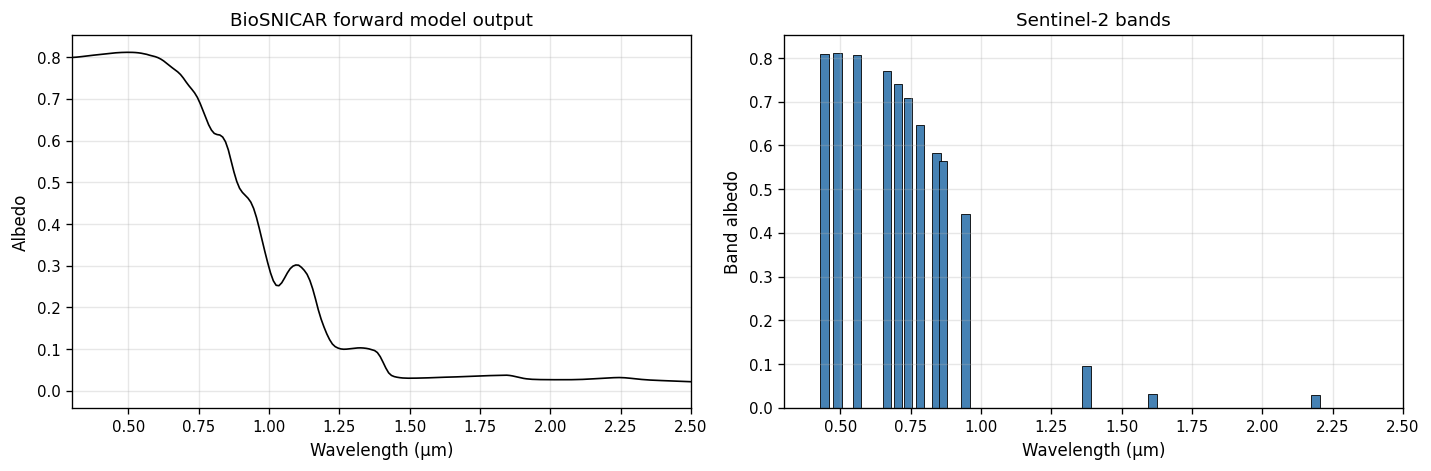

In [26]:
# --- Section 24: Full BioSNICAR capstone ---

if not BIOSNICAR_AVAILABLE:
    print("=" * 60)
    print("BioSNICAR not installed — skipping capstone section.")
    print("Install with: pip install -e /path/to/biosnicar-py")
    print("=" * 60)
else:
    from biosnicar import run_model
    from biosnicar.emulator import Emulator
    import os

    # Step 1: Run forward model for known surface
    print("Step 1: Running forward model...")
    outputs = run_model(rds=800, rho=600, dz=1.0, solzen=50,
                        black_carbon=50, direct=1)
    ssa_true = compute_ssa(800, 917)
    print(f"  BBA = {outputs.BBA:.4f}")
    print(f"  True SSA = {ssa_true:.1f} m²/kg (rds=800 µm)")

    # Step 2: Convert to Sentinel-2 bands
    print("\nStep 2: Converting to Sentinel-2 bands...")
    s2_result = outputs.to_platform("sentinel2")
    print(f"  B3 (Green): {s2_result.B3:.4f}")
    print(f"  B11 (SWIR): {s2_result.B11:.4f}")
    print(f"  NDSI: {s2_result.NDSI:.4f}")

    # Step 3: Also try standalone to_platform()
    print("\nStep 3: Standalone to_platform()...")
    s2_standalone = biosnicar.to_platform(outputs.albedo, "sentinel2",
                                           flx_slr=outputs.flx_slr)
    print(f"  B3 match: {abs(s2_result.B3 - s2_standalone.B3) < 1e-10}")

    # Step 4: Load emulator
    print("\nStep 4: Loading emulator...")
    emu_path = os.path.join(os.path.dirname(biosnicar.__file__), "..",
                             "data", "emulators", "glacier_ice_8_param_default.npz")
    if os.path.exists(emu_path):
        emu = Emulator.load(emu_path)
        print(f"  Emulator params: {emu.param_names}")
        print("\nStep 5: Capstone complete.")
        print("  Best practice: retrieve SSA (not rds) using retrieve().")
        print("  The retrieval system handles the rds→SSA mapping internally.")
    else:
        print(f"  Default emulator not found at: {emu_path}")

    # Plot forward model output
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(WVL, outputs.albedo, "k-", lw=1)
    ax1.set(xlabel="Wavelength (µm)", ylabel="Albedo", xlim=(0.3, 2.5),
            title="BioSNICAR forward model output")

    centres = [0.443, 0.490, 0.560, 0.665, 0.705, 0.740, 0.783,
               0.842, 0.865, 0.945, 1.375, 1.610, 2.190]
    band_vals = [getattr(s2_result, n) for n in s2_result.band_names]
    ax2.bar(centres, band_vals, width=0.03, color="steelblue",
            edgecolor="k", linewidth=0.5)
    ax2.set(xlabel="Wavelength (µm)", ylabel="Band albedo",
            xlim=(0.3, 2.5), title="Sentinel-2 bands")

    fig.tight_layout()
    plt.show()

**Figure 22** *(optional — requires BioSNICAR).* Output of the full
BioSNICAR adding-doubling forward model for a glacier surface (rds =
800 µm, ρ = 600 kg m⁻³, BC = 50 ppb).  *(Left)* The 480-band
spectral albedo showing all ice absorption features at their
physically correct depths.  *(Right)* The same spectrum convolved to
Sentinel-2's 13 bands, ready for comparison with satellite
observations.

## Section 25: Summary and Decision Guide

### What We Covered

| Act | Topic | Key takeaway |
|-----|-------|-------------|
| I | What Satellites See | Spectra → bands via flux-weighted SRF convolution |
| II | Bridging Spectra and Bands | ~3–4 independent DOF from 13 S2 bands |
| III | The Inverse Problem | Retrieve SSA (not rds); log-space; masking; regularisation |
| IV | Emulators | 10⁴× speedup enables practical retrieval |
| V | Scenarios | Fix what you know; 2–3 free params max |
| VI | Full Pipeline | `run_model()` → `to_platform()` → `retrieve()` |

### Decision Tree: Choosing a Platform

```
Do you need per-band spectral detail?
├─ YES → Do you need SWIR coverage?
│        ├─ YES → Sentinel-2 (13 bands, 0.44–2.19 µm)
│        │        or Landsat 8 (7 bands, 0.44–2.20 µm)
│        └─ NO  → Sentinel-3 OLCI (21 VIS-NIR bands, high revisit)
│                  or MODIS (7 bands, daily global)
└─ NO  → Broadband albedo for energy budget?
         ├─ YES → CESM2 2-band (VIS + NIR)
         │        or MAR (4 bands) / HadCM3 (6 bands)
         └─ NO  → CESM RRTMG (14 bands, radiative transfer detail)
```

### Decision Tree: Choosing a Retrieval Method

```
What to retrieve?
├─ SSA only          → L-BFGS-B (fast, reliable)
├─ SSA + 1 impurity  → Hybrid DE + L-BFGS-B (global → local)
├─ SSA + 2 impurities → Possible if bands are informative; test carefully
├─ 4+ params         → Reduce! Fix some with ancillary data.
└─ Uncertainty?
   ├─ Quick estimate → Hessian (seconds)
   └─ Full posterior → MCMC (minutes with emulator)
```

**Always retrieve SSA**, not grain radius.  SSA is the optically
meaningful variable; rds and ρ are degenerate (Section 11).

### Pitfall Checklist

- [ ] Are you retrieving SSA (not rds/ρ separately)?
- [ ] Did you fix solar zenith (known from orbit/time)?
- [ ] Did you mask atmospheric absorption bands (1.4, 1.9 µm)?
- [ ] Is dust really constrained, or should you fix it?
- [ ] Are you retrieving fewer parameters than effective DOF?
- [ ] Did you check for convergence (cost plateau, Hessian condition)?

### BioSNICAR Code Map

```
biosnicar/
├── drivers/run_model.py      # Forward model entry point
├── bands/
│   ├── __init__.py            # to_platform(), BandResult
│   ├── _core.py               # WVL, srf_convolve(), interval_average()
│   ├── platforms/             # sentinel2.py, sentinel3.py, landsat8.py, modis.py
│   └── gcm/                   # cesm.py, mar.py, hadcm3.py
├── emulator.py                # Emulator.build(), .predict(), .verify()
└── inverse/
    ├── optimize.py            # retrieve(), _LOG_SPACE_PARAMS
    ├── cost.py                # spectral_cost(), band_cost()
    └── result.py              # RetrievalResult, _compute_ssa()
```

In [27]:
# --- Section 25: Summary ---

print("Notebook complete!")
print()
print("Key functions used:")
print("  toy_spectrum()       — Parametric forward model (480 bands, SSA-based)")
print("  toy_to_platform()    — SRF convolution to satellite bands")
print("  toy_retrieve()       — Parameter retrieval via optimisation")
print("  ToyEmulator          — Lightweight emulator for fast evaluation")
print()
print("BioSNICAR equivalents:")
print("  biosnicar.run_model()           → 480-band spectral albedo")
print("  biosnicar.to_platform()         → Satellite band values")
print("  biosnicar.inverse.retrieve()    → Physical parameter retrieval")
print("  biosnicar.emulator.Emulator     → ML emulator (PCA + MLP)")
print()
print("Best practice: always retrieve SSA, not grain radius.")

Notebook complete!

Key functions used:
  toy_spectrum()       — Parametric forward model (480 bands, SSA-based)
  toy_to_platform()    — SRF convolution to satellite bands
  toy_retrieve()       — Parameter retrieval via optimisation
  ToyEmulator          — Lightweight emulator for fast evaluation

BioSNICAR equivalents:
  biosnicar.run_model()           → 480-band spectral albedo
  biosnicar.to_platform()         → Satellite band values
  biosnicar.inverse.retrieve()    → Physical parameter retrieval
  biosnicar.emulator.Emulator     → ML emulator (PCA + MLP)

Best practice: always retrieve SSA, not grain radius.
